## Selección del mejor modelo de Machine Learning

**Proyecto:** Predicción del precio mediano de viviendas en Boston (`medv`)
**Autora:** Maricel Martinez
**Notebook:** `08.model_selection` — Issue 6

### Descripción

En este notebook se realiza el proceso de **selección del mejor modelo de machine learning**
para predecir `medv`. El proceso se hace de forma **manual** (no con AutoML) siguiendo los pasos
del curso, y el criterio de éxito es explícito: el modelo elegido debe **superar al modelo base
(heurístico) construido en el notebook 07**.

Se sigue esta secuencia:

1. Reutilizar el pipeline de procesamiento de datos del notebook 06.
2. Dividir en Train / Test con **exactamente la misma partición del notebook 07** (para que la
   comparación contra el baseline sea válida).
3. Evaluar **10 modelos de 5 familias distintas** con las mismas métricas del notebook 07.
4. **Descartar los modelos que quedan por debajo del promedio** del grupo.
5. Evaluar los modelos restantes con **validación cruzada** (media y desviación estándar).
6. Optimizar los **hiperparámetros de los 3 mejores** con búsqueda aleatoria y validación cruzada.
7. Comparar con **pruebas estadísticas** (ANOVA, Friedman y t de Student por pares con
   corrección de Holm) y seleccionar el mejor modelo.
8. Entrenar con todo el conjunto de entrenamiento, evaluar en test y diagnosticar
   **overfitting / underfitting**.
9. Analizar **learning curve**, **escalabilidad** e **importancia de variables**.
10. Guardar el pipeline completo (preprocesamiento + modelo) y sus métricas.

> Todo el proceso de selección se hace **solo con el conjunto de entrenamiento**. El conjunto de
> prueba se usa una única vez, al final, para reportar el desempeño del modelo ya elegido.

## 📚 Import libraries

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from IPython.display import Markdown, display
from scipy.stats import f_oneway, friedmanchisquare, ttest_rel
from sklearn import set_config
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    ShuffleSplit,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

### Configuración y versiones

In [ ]:
pd.set_option("display.float_format", "{:.4f}".format)

# los transformadores devuelven DataFrame en lugar de ndarray
set_config(transform_output="pandas")

# mismos parámetros del notebook 07: la partición y los folds deben ser idénticos
# para que la comparación contra el modelo base sea válida
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 10

# parámetros propios de este notebook
N_SPLITS_SCREENING = 5  # folds de la primera evaluación (más rápida)
N_ITER_SEARCH = 40  # combinaciones probadas por RandomizedSearchCV
TOP_N_TUNING = 3  # modelos que pasan a optimización de hiperparámetros
MIN_MODELS_KEPT = 3  # mínimo de modelos que sobreviven al descarte
ALPHA = 0.05  # nivel de significancia de las pruebas estadísticas

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("sklearn version:", sk.__version__)
print("joblib version:", joblib.__version__)

Pandas version: 3.0.5
Numpy version: 2.5.2
sklearn version: 1.9.0
joblib version: 1.5.3


## 💾 Load data

In [3]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = DATA_DIR / "06_models"
MODEL_OUTPUT_DIR = DATA_DIR / "07_model_output"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet", engine="pyarrow"
)
print("Datos originales:", boston_df.shape)

Datos originales: (343, 14)


# 👷 Preparación de datos

Se repiten exactamente los mismos pasos del notebook 07 (que a su vez vienen del notebook 06):
eliminar duplicados, eliminar filas sin variable objetivo, marcar la censura de `medv = 50`,
descartar `tax` por colinealidad con `rad` y crear el atributo `rad_group`.

In [4]:
MEDV_CENSORED_VALUE = 50.0
RAD_HIGH_VALUE = 24

selected_features = [
    "crim",
    "zn",
    "indus",
    "chas",
    "nox",
    "rm",
    "age",
    "dis",
    "rad",
    "tax",
    "ptratio",
    "black",
    "lstat",
    "medv",
]

boston_features = boston_df[selected_features].copy()

# 1. filas duplicadas
duplicated_rows = boston_features.duplicated().sum()
boston_features = boston_features.drop_duplicates()

# 2. filas sin variable objetivo
missing_target = boston_features["medv"].isna().sum()
boston_features = boston_features.dropna(subset=["medv"])

# 3. marcar posible censura en medv (no se eliminan las filas)
boston_features["medv_censored"] = (boston_features["medv"] == MEDV_CENSORED_VALUE).astype(int)

# 4. feature selection: se descarta tax por colinealidad con rad
boston_features = boston_features.drop(columns=["tax"])

# 5. nuevo atributo rad_group
boston_features["rad_group"] = np.where(boston_features["rad"] == RAD_HIGH_VALUE, "alto", "bajo")

print("Filas duplicadas eliminadas:", duplicated_rows)
print("Filas sin medv eliminadas:", missing_target)
print("Dataset preparado:", boston_features.shape)
print("Observaciones censuradas (medv = 50):", boston_features["medv_censored"].sum())

Filas duplicadas eliminadas: 10
Filas sin medv eliminadas: 12
Dataset preparado: (321, 15)
Observaciones censuradas (medv = 50): 11


## 🚨 Corrección respecto al notebook 07: `medv_censored` no puede ser un atributo

Al revisar el pipeline heredado se detectó un problema que había que resolver **antes** de
entrenar modelos de machine learning: la columna `medv_censored` estaba incluida entre las
variables binarias del `ColumnTransformer`, pero **se calcula a partir de la variable objetivo**
(`medv == 50`). Usarla como predictora es una **fuga de la variable objetivo (target leakage)**:
le estaría diciendo al modelo exactamente qué viviendas valen 50.

Un árbol o un modelo de boosting aprendería de inmediato la regla "si `medv_censored = 1`,
predice 50", lo que produciría un score de validación cruzada artificialmente bueno e imposible
de reproducir en producción, donde esa columna no existe (no se conoce el precio de una vivienda
antes de predecirlo).

**Por qué esto no invalida el notebook 07:** allí los modelos base no usaban esa columna. Los
`DummyRegressor` no usan ninguna variable predictora, y el modelo heurístico solo recibía `rm` y
`lstat` a través de `heuristic_preprocessor`. El baseline de referencia (RMSE de validación
cruzada) sigue siendo válido y comparable.

**Decisión:** en este notebook `medv_censored` se excluye de la matriz de atributos y se conserva
**por separado** como metadato, únicamente para el análisis de error por subgrupo al final.

In [5]:
# medv_censored se separa de los atributos: es información derivada del target
censored_flag = boston_features["medv_censored"].copy()

X_features = boston_features.drop(columns=["medv", "medv_censored"])
y_target = boston_features["medv"]

print("Atributos disponibles:", X_features.shape[1])
print("Columnas:", list(X_features.columns))
print("Variable objetivo:", y_target.name, "| observaciones:", len(y_target))

Atributos disponibles: 13
Columnas: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'ptratio', 'black', 'lstat', 'rad_group']
Variable objetivo: medv | observaciones: 321


# ⚙️ Pipeline de procesamiento de datos (reutilizado del notebook 06)

Se reutiliza el mismo pipeline construido en el notebook de feature engineering, con el único
cambio de quitar `medv_censored` de las variables binarias por la razón explicada arriba. El
pipeline queda entonces con **23 columnas de salida** en lugar de 24.

Cada grupo de columnas recibe el tratamiento que se justificó en el notebook 06:

| Grupo | Columnas | Transformación |
| --- | --- | --- |
| `log` | `crim` | imputación por mediana → `log1p` → estandarización |
| `numeric` | `zn`, `indus`, `nox`, `rm`, `age`, `dis`, `ptratio`, `black`, `lstat` | imputación por mediana → estandarización |
| `discretize` | `age` | imputación por mediana → discretización en 4 cuartiles |
| `binary` | `chas` | imputación por moda |
| `nominal` | `rad`, `rad_group` | imputación por moda → One-Hot |

In [6]:
cols_log = ["crim"]

cols_numeric = ["zn", "indus", "nox", "rm", "age", "dis", "ptratio", "black", "lstat"]

cols_discretize = ["age"]

# medv_censored ya no está aquí: se calcula a partir de la variable objetivo
cols_binary = ["chas"]

cols_nominal = ["rad", "rad_group"]

In [7]:
# Pipeline: variable con transformación logarítmica antes de escalar
log_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline: variables numéricas continuas
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline: discretización de age en 4 categorías (nuevo atributo)
discretize_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "discretizer",
            KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile"),
        ),
    ]
)

# Pipeline: variables binarias (ya en 0/1, solo se imputan por seguridad)
binary_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

# Pipeline: variables categóricas nominales
nominal_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("log", log_pipe, cols_log),
        ("numeric", numeric_pipe, cols_numeric),
        ("discretize", discretize_pipe, cols_discretize),
        ("binary", binary_pipe, cols_binary),
        ("nominal", nominal_pipe, cols_nominal),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

# ✂️ Train / Test split

Se usa **exactamente la misma partición del notebook 07**: 80 % entrenamiento y 20 % prueba,
estratificada por `chas` y con `random_state=42`.

Esto es importante: `train_test_split` decide qué filas van a cada conjunto en función del número
de observaciones, la variable de estratificación, `test_size` y `random_state`, **no** del número
de columnas. Al haber quitado `medv_censored` de los atributos, las filas de entrenamiento y de
prueba siguen siendo las mismas 256 y 65 del notebook anterior, así que el RMSE del modelo base
es directamente comparable con los resultados de este notebook.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=TEST_SIZE,
    stratify=X_features["chas"],
    random_state=RANDOM_STATE,
)

# la marca de censura se conserva alineada por índice, fuera de los atributos
censored_train = censored_flag.loc[x_train.index]
censored_test = censored_flag.loc[x_test.index]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (256, 13) (256,)
Test : (65, 13) (65,)


In [10]:
# verificación de que no hay fuga de datos entre los dos conjuntos
shared_rows = set(x_train.index) & set(x_test.index)
print("Filas compartidas entre train y test:", len(shared_rows))
print("Filas duplicadas en train:", int(x_train.duplicated().sum()))

print(
    "Censurados en train:",
    int(censored_train.sum()),
    "| en test:",
    int(censored_test.sum()),
)
print("Media de medv en train:", round(y_train.mean(), 4))
print("Media de medv en test :", round(y_test.mean(), 4))
print("Desviación de medv en train:", round(y_train.std(), 4))
print("Desviación de medv en test :", round(y_test.std(), 4))

Filas compartidas entre train y test: 0
Filas duplicadas en train: 0
Censurados en train: 11 | en test: 0
Media de medv en train: 23.0496
Media de medv en test : 21.6323
Desviación de medv en train: 9.7588
Desviación de medv en test : 6.707


#### Interpretación

La partición reproduce la del notebook 07: **256 filas de entrenamiento y 65 de prueba**, sin
filas compartidas ni duplicadas. Se confirma también lo que se documentó allí como limitación:
las **11 viviendas censuradas en `medv = 50` quedaron todas en entrenamiento**, y el conjunto de
prueba es menos disperso que el de entrenamiento. Por eso la comparación principal entre modelos
se hace sobre el **RMSE de validación cruzada**, y el conjunto de prueba se reserva para la
verificación final del modelo ya seleccionado.

In [11]:
x_train_transformed = preprocessor.fit_transform(x_train)

print("Dimensiones tras el preprocesamiento:", x_train_transformed.shape)
print("Valores nulos:", int(x_train_transformed.isna().sum().sum()))
print("Columnas de salida:")
print(list(x_train_transformed.columns))

Dimensiones tras el preprocesamiento: (256, 23)
Valores nulos: 0
Columnas de salida:
['log__crim', 'numeric__zn', 'numeric__indus', 'numeric__nox', 'numeric__rm', 'numeric__age', 'numeric__dis', 'numeric__ptratio', 'numeric__black', 'numeric__lstat', 'discretize__age', 'binary__chas', 'nominal__rad_1.0', 'nominal__rad_2.0', 'nominal__rad_3.0', 'nominal__rad_4.0', 'nominal__rad_5.0', 'nominal__rad_6.0', 'nominal__rad_7.0', 'nominal__rad_8.0', 'nominal__rad_24.0', 'nominal__rad_group_alto', 'nominal__rad_group_bajo']


#### Interpretación

El pipeline entrega **256 filas y 23 columnas** sin valores nulos: una menos que en el notebook 07
justamente porque se eliminó `binary__medv_censored`. El desglose es 1 columna de `crim`
transformada con logaritmo, 9 numéricas escaladas, 1 `age` discretizada, 1 binaria (`chas`) y 11
columnas de One-Hot de `rad` y `rad_group`.

Vale la pena anotar una redundancia conocida: `rad_group_alto` es equivalente a `rad_24.0`, porque
el grupo "alto" se definió como `rad == 24`. No se elimina porque no afecta a los modelos
regularizados ni a los basados en árboles, pero es un candidato claro de limpieza si más adelante
se quiere un modelo lineal sin colinealidad.

# 📥 Modelo base del notebook 07 (la referencia a superar)

El requerimiento es explícito: el modelo seleccionado **debe ser mejor que el modelo base**. Para
que la comparación no dependa de números copiados a mano, se carga el pipeline guardado en el
notebook 07 (`baseline_model.joblib`) junto con su archivo de métricas (`baseline_metrics.json`).

**Detalle técnico importante:** ese `.joblib` contiene un pipeline cuyo último paso es la clase
`HeuristicRegressor`, definida a mano en el notebook 07. `joblib` (como `pickle`) **no guarda el
código de la clase, solo una referencia a ella**, así que la clase tiene que existir en el espacio
de nombres antes de cargar el archivo; si no, la carga falla con
`AttributeError: Can't get attribute 'HeuristicRegressor'`. Por eso se vuelve a declarar aquí,
idéntica a la del notebook anterior.

Esto es también un aprendizaje para producción: un modelo con clases propias no es portable por sí
solo. Lo correcto es mover `HeuristicRegressor` a un módulo de `src/` e importarlo, tanto en el
notebook como en el servicio que consuma el modelo.

In [12]:
RM_HIGH = 7.0
LSTAT_LOW = 10.0
LSTAT_HIGH = 20.0
N_HEURISTIC_FEATURES = 2
EXPECTED_NDIM = 2
SEGMENT_NAMES = ("premium", "alto", "medio", "bajo")


class HeuristicRegressor(BaseEstimator, RegressorMixin):
    """Modelo heurístico de regresión para medv, definido en el notebook 07.

    Se declara de nuevo aquí porque joblib guarda una referencia a la clase y no
    su código: sin esta definición, cargar baseline_model.joblib falla.
    """

    def __init__(self, rm_high=RM_HIGH, lstat_low=LSTAT_LOW, lstat_high=LSTAT_HIGH):
        self.rm_high = rm_high
        self.lstat_low = lstat_low
        self.lstat_high = lstat_high

    def _segments(self, X):
        data = np.asarray(X, dtype=float)
        if data.ndim != EXPECTED_NDIM or data.shape[1] != N_HEURISTIC_FEATURES:
            msg = "HeuristicRegressor espera 2 columnas de entrada: rm y lstat"
            raise ValueError(msg)

        rm_values = data[:, 0]
        lstat_values = data[:, 1]

        conditions = [
            (rm_values >= self.rm_high) & (lstat_values < self.lstat_low),
            lstat_values < self.lstat_low,
            lstat_values < self.lstat_high,
        ]
        return np.select(conditions, list(SEGMENT_NAMES[:-1]), default=SEGMENT_NAMES[-1])

    def fit(self, X, y):
        segments = self._segments(X)
        target = np.asarray(y, dtype=float)

        self.global_value_ = float(np.median(target))
        self.segment_values_ = {}
        self.segment_counts_ = {}

        for segment in SEGMENT_NAMES:
            mask = segments == segment
            self.segment_counts_[segment] = int(mask.sum())
            self.segment_values_[segment] = (
                float(np.median(target[mask])) if mask.any() else self.global_value_
            )

        self.n_features_in_ = N_HEURISTIC_FEATURES
        self.is_fitted_ = True
        return self

    def predict(self, X):
        segments = self._segments(X)
        return np.array([self.segment_values_[segment] for segment in segments])

In [13]:
baseline_path = MODELS_DIR / "baseline_model.joblib"
baseline_metrics_path = MODEL_OUTPUT_DIR / "baseline_metrics.json"

baseline_pipeline = joblib.load(baseline_path)

with baseline_metrics_path.open(encoding="utf-8") as metrics_file:
    baseline_metrics = json.load(metrics_file)

BASELINE_NAME = baseline_metrics["model"]
BASELINE_CV_MEAN = baseline_metrics["cross_validation"]["RMSE"]["cv_mean"]
BASELINE_CV_STD = baseline_metrics["cross_validation"]["RMSE"]["cv_std"]
BASELINE_TEST = baseline_metrics["test"]
DUMMY_TEST = baseline_metrics["dummy_reference_test"]

print("Pipeline base cargado:", type(baseline_pipeline).__name__)
print("Pasos:", list(baseline_pipeline.named_steps))
print("Modelo base:", BASELINE_NAME)
print("Variable más importante (nb 07):", baseline_metrics["most_important_feature"])
print(f"RMSE de validación cruzada: {BASELINE_CV_MEAN:.4f} ± {BASELINE_CV_STD:.4f}")
print("Métricas en test:", {k: round(v, 4) for k, v in BASELINE_TEST.items()})

Pipeline base cargado: Pipeline
Pasos: ['preprocessor', 'model']
Modelo base: heuristic
Variable más importante (nb 07): lstat
RMSE de validación cruzada: 5.4837 ± 1.0528
Métricas en test: {'MAE': 2.9962, 'RMSE': 4.0208, 'R2': 0.635, 'MAPE': 0.1505}


### Criterio de aceptación definido *antes* de entrenar

En las recomendaciones del notebook 07 se fijó el criterio de aceptación: un modelo nuevo solo se
considera mejor si **reduce el RMSE de validación cruzada del baseline en al menos una desviación
estándar entre folds**. Definirlo antes de ver los resultados evita el sesgo de justificar después
cualquier mejora decimal que en realidad esté dentro del ruido.

In [ ]:
ACCEPTANCE_RMSE = BASELINE_CV_MEAN - BASELINE_CV_STD
baseline_cv_text = f"{BASELINE_CV_MEAN:.4f} ± {BASELINE_CV_STD:.4f}"

display(
    Markdown(
        f"""
**Criterio de aceptación de este notebook**

| Referencia | RMSE (miles de USD) |
| --- | --- |
| Dummy (media) del notebook 07 | {DUMMY_TEST["RMSE"]:.4f} en test |
| Modelo base `{BASELINE_NAME}` en validación cruzada | **{baseline_cv_text}** |
| Umbral que hay que bajar | **≤ {ACCEPTANCE_RMSE:.4f}** |

Un modelo con RMSE de validación cruzada entre {ACCEPTANCE_RMSE:.4f} y
{BASELINE_CV_MEAN:.4f} mejora al baseline, pero dentro del ruido entre folds: se
reportaría como una mejora no concluyente.
"""
    )
)


**Criterio de aceptación de este notebook**

| Referencia | RMSE (miles de USD) |
| --- | --- |
| Dummy (media) del notebook 07 | 6.8045 en test |
| Modelo base `heuristic` en validación cruzada | **5.4837 ± 1.0528** |
| Umbral que hay que bajar | **≤ 4.4310** |

Un modelo con RMSE de validación cruzada entre 4.4310 y
5.4837 mejora al baseline, pero dentro del ruido entre folds: se
reportaría como una mejora no concluyente.


# 📏 Métricas de evaluación

Se usan las mismas cuatro métricas del notebook 07, con **RMSE como métrica de decisión**
(justificada allí: penaliza los errores grandes, que en una valoración de vivienda son los
costosos, y está en las mismas unidades que `medv`).

In [15]:
scoring_metrics = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error",
}

MAIN_METRIC = "RMSE"
MAIN_SCORER = scoring_metrics[MAIN_METRIC]

# los mismos folds del notebook 07: misma semilla y mismo número de particiones
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
kfold_screening = KFold(n_splits=N_SPLITS_SCREENING, shuffle=True, random_state=RANDOM_STATE)

print("Métrica de decisión:", MAIN_METRIC, "->", MAIN_SCORER)
print("Folds de validación cruzada:", N_SPLITS)
print("Folds del descarte inicial:", N_SPLITS_SCREENING)

Métrica de decisión: RMSE -> neg_root_mean_squared_error
Folds de validación cruzada: 10
Folds del descarte inicial: 5


# 🤖 Selección inicial de modelos

El requerimiento pide **mínimo 4 tipos diferentes** de modelos. Se evalúan **10 modelos de 5
familias distintas**, todos con hiperparámetros por defecto (salvo lo mínimo para que converjan),
porque en esta primera fase el objetivo es descartar, no afinar:

| Familia | Modelos | Por qué se incluye |
| --- | --- | --- |
| Lineales regularizados | `Ridge`, `Lasso`, `ElasticNet` | interpretables y buena línea de referencia; el notebook 07 mostró que `lstat` y `rm` tienen relación fuerte con `medv` |
| Basados en distancia | `KNeighborsRegressor` | el pipeline ya escala las variables, requisito para que la distancia tenga sentido |
| Máquinas de vectores de soporte | `SVR` (kernel RBF) | capta relaciones no lineales sin ser un ensamble de árboles |
| Árbol individual | `DecisionTreeRegressor` | es la versión "que aprende sus propios umbrales" del modelo heurístico del notebook 07 |
| Ensambles de árboles | `RandomForest`, `ExtraTrees`, `GradientBoosting`, `HistGradientBoosting` | suelen ser el estado del arte en datos tabulares; bagging y boosting funcionan de forma distinta |

Todos se envuelven en un `Pipeline` con el mismo `preprocessor`, de modo que la imputación, el
escalado y el One-Hot **se ajustan dentro de cada fold** de la validación cruzada y no antes. Es la
única forma de que la estimación del error no esté contaminada.

In [ ]:
def build_pipeline(model):
    """Une el preprocesamiento reutilizado con un modelo de scikit-learn."""
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


candidate_models = {
    "ridge": build_pipeline(Ridge(random_state=RANDOM_STATE)),
    "lasso": build_pipeline(Lasso(max_iter=5000, random_state=RANDOM_STATE)),
    "elastic_net": build_pipeline(ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
    "knn": build_pipeline(KNeighborsRegressor()),
    "svr": build_pipeline(SVR()),
    "decision_tree": build_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "random_forest": build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    "extra_trees": build_pipeline(ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    "gradient_boosting": build_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "hist_gradient_boosting": build_pipeline(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    ),
}

print("Modelos candidatos:", len(candidate_models))
for name in candidate_models:
    print(" -", name)

Modelos candidatos: 10
 - ridge
 - lasso
 - elastic_net
 - knn
 - svr
 - decision_tree
 - random_forest
 - extra_trees
 - gradient_boosting
 - hist_gradient_boosting


## Primera evaluación y descarte de los modelos por debajo del promedio

Aquí hay una diferencia deliberada con el ejemplo del profesor. En su notebook, el descarte inicial
se hace entrenando cada modelo y midiéndolo **en el conjunto de prueba**; además la función
`build_model` vuelve a partir los datos por dentro con otra semilla y sobre el DataFrame sin
deduplicar, así que ni usa la partición que se creó antes ni evita los duplicados entre train y
test.

Elegir modelos mirando el conjunto de prueba lo convierte en parte del entrenamiento: el error que
se reporta al final queda optimista y ya no estima el desempeño con datos nuevos. Aquí el descarte
se hace con **validación cruzada de 5 folds sobre el conjunto de entrenamiento**, que es más
estable que una sola partición y no toca el conjunto de prueba.

Se guarda también el score de entrenamiento para tener una primera señal de sobreajuste.

In [17]:
screening_records = []

for name, pipe in candidate_models.items():
    result = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=kfold_screening,
        scoring=[MAIN_SCORER, "r2"],
        return_train_score=True,
        n_jobs=-1,
    )
    cv_rmse = -result[f"test_{MAIN_SCORER}"]
    train_rmse = -result[f"train_{MAIN_SCORER}"]
    screening_records.append(
        {
            "modelo": name,
            "cv_rmse": cv_rmse.mean(),
            "cv_std": cv_rmse.std(),
            "train_rmse": train_rmse.mean(),
            "cv_r2": result["test_r2"].mean(),
            "gap": cv_rmse.mean() - train_rmse.mean(),
            "fit_time": result["fit_time"].mean(),
        }
    )

screening_df = pd.DataFrame(screening_records).set_index("modelo")
screening_df = screening_df.sort_values("cv_rmse")
screening_df

,cv_rmse,cv_std,train_rmse,cv_r2,gap,fit_time
modelo,,,,,,
gradient_boosting,3.2232,0.3186,0.8905,0.8855,2.3327,0.3496
random_forest,3.4337,0.4431,1.4070,0.8689,2.0266,0.8180
extra_trees,3.4574,0.6171,0.0000,0.8641,3.4574,0.4747
hist_gradient_boosting,3.8614,0.6417,1.8467,0.8320,2.0147,0.3092
decision_tree,4.5235,0.9812,0.0000,0.7756,4.5235,0.2091
knn,5.0425,1.2305,4.0720,0.7099,0.9705,0.2923
ridge,5.2632,0.5908,4.8083,0.6865,0.4549,1.1859
lasso,5.9468,0.5166,5.6901,0.6032,0.2567,10.3410
elastic_net,6.0902,0.4403,5.8839,0.5884,0.2063,0.5516


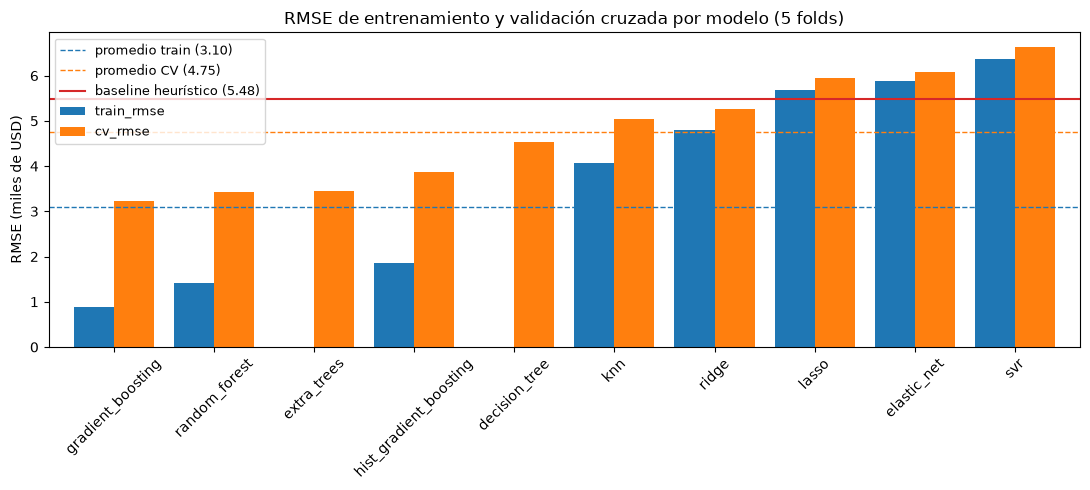

In [18]:
mean_cv_rmse = screening_df["cv_rmse"].mean()
mean_train_rmse = screening_df["train_rmse"].mean()

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = screening_df[["train_rmse", "cv_rmse"]]
plot_df.plot(kind="bar", ax=ax, rot=45, width=0.8)

ax.axhline(
    mean_train_rmse,
    color="tab:blue",
    linestyle="--",
    linewidth=1,
    label=f"promedio train ({mean_train_rmse:.2f})",
)
ax.axhline(
    mean_cv_rmse,
    color="tab:orange",
    linestyle="--",
    linewidth=1,
    label=f"promedio CV ({mean_cv_rmse:.2f})",
)
ax.axhline(
    BASELINE_CV_MEAN,
    color="tab:red",
    linestyle="-",
    linewidth=1.5,
    label=f"baseline heurístico ({BASELINE_CV_MEAN:.2f})",
)

ax.set_title("RMSE de entrenamiento y validación cruzada por modelo (5 folds)")
ax.set_ylabel("RMSE (miles de USD)")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Regla de descarte

El requerimiento dice: *"eliminar los modelos que funcionen por debajo del promedio de los
modelos"*. Como la métrica de decisión es un error, "funcionar por debajo del promedio" significa
**tener un RMSE de validación cruzada mayor que el promedio del grupo**.

Se añade una salvaguarda: si la regla dejara menos de `MIN_MODELS_KEPT` modelos, se conservan los
mejores `MIN_MODELS_KEPT` de todos modos, porque el paso siguiente del requerimiento pide optimizar
los hiperparámetros de **dos o tres** modelos y hace falta ese mínimo para poder comparar con
pruebas estadísticas.

In [19]:
kept_models = screening_df.index[screening_df["cv_rmse"] <= mean_cv_rmse].tolist()

if len(kept_models) < MIN_MODELS_KEPT:
    kept_models = screening_df.index[:MIN_MODELS_KEPT].tolist()

discarded_models = [name for name in screening_df.index if name not in kept_models]

selected_models = {name: candidate_models[name] for name in kept_models}

print(f"Promedio de RMSE en validación cruzada: {mean_cv_rmse:.4f}")
print("Modelos conservados:", len(kept_models))
for name in kept_models:
    print(f"  ✅ {name:<24} RMSE CV = {screening_df.loc[name, 'cv_rmse']:.4f}")
print("Modelos descartados:", len(discarded_models))
for name in discarded_models:
    print(f"  ❌ {name:<24} RMSE CV = {screening_df.loc[name, 'cv_rmse']:.4f}")

Promedio de RMSE en validación cruzada: 4.7468
Modelos conservados: 5
  ✅ gradient_boosting        RMSE CV = 3.2232
  ✅ random_forest            RMSE CV = 3.4337
  ✅ extra_trees              RMSE CV = 3.4574
  ✅ hist_gradient_boosting   RMSE CV = 3.8614
  ✅ decision_tree            RMSE CV = 4.5235
Modelos descartados: 5
  ❌ knn                      RMSE CV = 5.0425
  ❌ ridge                    RMSE CV = 5.2632
  ❌ lasso                    RMSE CV = 5.9468
  ❌ elastic_net              RMSE CV = 6.0902
  ❌ svr                      RMSE CV = 6.6261


In [ ]:
best_screening = screening_df.index[0]
beat_baseline = screening_df.index[screening_df["cv_rmse"] < BASELINE_CV_MEAN].tolist()
n_below_acceptance = int((screening_df["cv_rmse"] <= ACCEPTANCE_RMSE).sum())
kept_text = ", ".join(f"`{name}`" for name in kept_models)
best_rmse = screening_df.loc[best_screening, "cv_rmse"]
best_std = screening_df.loc[best_screening, "cv_std"]

display(
    Markdown(
        f"""
**Resultado del descarte inicial**

- Promedio del grupo: **{mean_cv_rmse:.4f}** de RMSE en validación cruzada.
- Se conservan **{len(kept_models)}** modelos y se descartan
  **{len(discarded_models)}**.
- Mejor modelo de esta primera pasada: **`{best_screening}`**
  ({best_rmse:.4f} ± {best_std:.4f}).
- Modelos que ya superan al baseline heurístico ({BASELINE_CV_MEAN:.4f}):
  **{len(beat_baseline)} de {len(screening_df)}**.
- Modelos que además cruzan el umbral de aceptación ({ACCEPTANCE_RMSE:.4f}):
  **{n_below_acceptance}**.

Modelos que pasan a la siguiente fase: {kept_text}.
"""
    )
)


**Resultado del descarte inicial**

- Promedio del grupo: **4.7468** de RMSE en validación cruzada.
- Se conservan **5** modelos y se descartan
  **5**.
- Mejor modelo de esta primera pasada: **`gradient_boosting`**
  (3.2232 ± 0.3186).
- Modelos que ya superan al baseline heurístico (5.4837):
  **7 de 10**.
- Modelos que además cruzan el umbral de aceptación (4.4310):
  **4**.

Modelos que pasan a la siguiente fase: `gradient_boosting`, `random_forest`, `extra_trees`, `hist_gradient_boosting`, `decision_tree`.


#### Interpretación

Las barras dejan ver tres comportamientos distintos:

- **Diferencia entre la barra azul y la naranja**: cuando el RMSE de entrenamiento es muy inferior
  al de validación cruzada, el modelo está memorizando. Es lo esperable en `decision_tree` y en los
  ensambles de árboles, que pueden ajustar cada observación de entrenamiento; la columna `gap` de la
  tabla lo cuantifica.
- **Modelos lineales**: sus dos barras quedan casi a la misma altura. No sobreajustan, pero su techo
  es más bajo porque `medv` no depende de forma lineal de `lstat` (en el notebook 07 esa relación
  resultó claramente curva).
- **Línea roja**: cualquier barra naranja por debajo de ella mejora al modelo heurístico del
  notebook 07. Superar el baseline es la condición mínima del requerimiento, pero para declarar una
  mejora sólida el modelo debe bajar del umbral de aceptación fijado antes de entrenar.

Los modelos descartados aquí no vuelven a aparecer: el resto del notebook trabaja solo con los
supervivientes.

# 🔁 Validación cruzada de los modelos supervivientes

Los modelos que pasaron el descarte se evalúan ahora con **validación cruzada de 10 folds**, los
mismos que se usaron en el notebook 07 (`KFold(n_splits=10, shuffle=True, random_state=42)`). Al
compartir semilla y número de particiones, cada modelo se mide sobre **exactamente los mismos
folds** que el modelo base, y las comparaciones por pares del paso siguiente son legítimas.

Dos decisiones de diseño:

1. Se calculan las **cuatro métricas** del notebook 07 (MAE, RMSE, R² y MAPE) en lugar de solo la
   principal, porque miden cosas distintas: el MAE es el error típico en miles de dólares, el RMSE
   castiga los errores grandes, el R² dice cuánta varianza se explica y el MAPE expresa el error en
   términos relativos al precio de la vivienda.
2. **El pipeline base del notebook 07 se incluye en la misma evaluación** en lugar de comparar
   contra un número copiado. Así aparece en las mismas tablas y en los mismos diagramas de caja, con
   sus mismos folds, y la mejora se puede medir fold a fold.

In [21]:
BASELINE_KEY = "baseline_heuristico"

models_to_validate = dict(selected_models)
models_to_validate[BASELINE_KEY] = baseline_pipeline

print("Modelos en validación cruzada:", len(models_to_validate))
print("Folds:", kfold.get_n_splits())

Modelos en validación cruzada: 6
Folds: 10


In [22]:
fold_records = []
summary_records = []

for name, pipe in models_to_validate.items():
    result = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=kfold,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1,
    )

    for metric, scorer in scoring_metrics.items():
        sign = -1.0 if scorer.startswith("neg_") else 1.0
        cv_values = sign * result[f"test_{metric}"]
        train_values = sign * result[f"train_{metric}"]

        for fold_index, value in enumerate(cv_values):
            fold_records.append(
                {
                    "modelo": name,
                    "metrica": metric,
                    "fold": fold_index,
                    "valor": value,
                }
            )

        summary_records.append(
            {
                "modelo": name,
                "metrica": metric,
                "cv_mean": cv_values.mean(),
                "cv_std": cv_values.std(),
                "train_mean": train_values.mean(),
                "fit_time": result["fit_time"].mean(),
                "score_time": result["score_time"].mean(),
            }
        )

cv_folds_df = pd.DataFrame(fold_records)
cv_summary_df = pd.DataFrame(summary_records)

print("Evaluaciones registradas:", len(cv_summary_df))
print("Mediciones por fold:", len(cv_folds_df))

Evaluaciones registradas: 24
Mediciones por fold: 240


## Resumen: media y desviación estándar por métrica

In [23]:
cv_rmse_df = (
    cv_summary_df[cv_summary_df["metrica"] == MAIN_METRIC]
    .set_index("modelo")
    .drop(columns="metrica")
    .sort_values(["cv_mean", "cv_std"])
)
cv_rmse_df["gap"] = cv_rmse_df["cv_mean"] - cv_rmse_df["train_mean"]

model_order = cv_rmse_df.index.tolist()

cv_mean_pivot = cv_summary_df.pivot(index="modelo", columns="metrica", values="cv_mean").loc[
    model_order
]
cv_std_pivot = cv_summary_df.pivot(index="modelo", columns="metrica", values="cv_std").loc[
    model_order
]

cv_mean_pivot

metrica,MAE,MAPE,R2,RMSE
modelo,,,,
gradient_boosting,2.2895,0.1140,0.8733,3.1064
random_forest,2.3961,0.1170,0.8527,3.4062
extra_trees,2.4279,0.1158,0.8261,3.5903
hist_gradient_boosting,2.7172,0.1293,0.8176,3.8528
decision_tree,3.2716,0.1644,0.6699,4.9823
baseline_heuristico,3.9920,0.1891,0.6000,5.4837


In [25]:
cv_std_pivot

metrica,MAE,MAPE,R2,RMSE
modelo,,,,
gradient_boosting,0.1959,0.0125,0.0684,0.3708
random_forest,0.2484,0.0178,0.0665,0.5912
extra_trees,0.4600,0.0220,0.1112,1.0740
hist_gradient_boosting,0.2639,0.0194,0.0650,0.5700
decision_tree,0.4870,0.0303,0.1856,1.4822
baseline_heuristico,0.5634,0.0212,0.2517,1.0528


In [26]:
cv_rmse_df

,cv_mean,cv_std,train_mean,fit_time,score_time,gap
modelo,,,,,,
gradient_boosting,3.1064,0.3708,0.9929,0.7231,0.1437,2.1135
random_forest,3.4062,0.5912,1.3053,0.9840,0.2274,2.1009
extra_trees,3.5903,1.0740,0.0000,0.6453,0.2550,3.5903
hist_gradient_boosting,3.8528,0.5700,1.7339,0.3988,0.0975,2.1189
decision_tree,4.9823,1.4822,0.0000,0.1619,0.0924,4.9823
baseline_heuristico,5.4837,1.0528,5.4434,0.0344,0.0249,0.0403


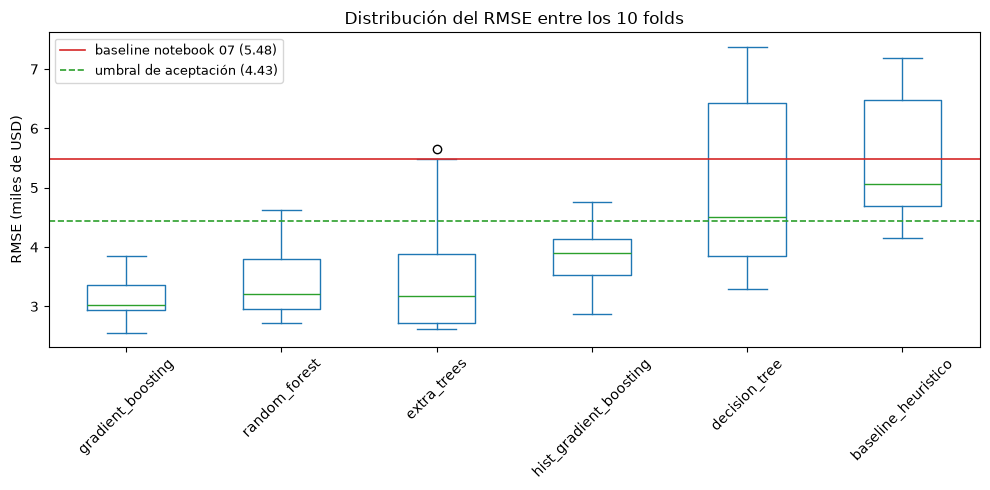

In [27]:
rmse_folds = (
    cv_folds_df[cv_folds_df["metrica"] == MAIN_METRIC]
    .pivot(index="fold", columns="modelo", values="valor")
    .loc[:, model_order]
)

fig, ax = plt.subplots(figsize=(10, 5))
rmse_folds.plot(kind="box", ax=ax, rot=45, grid=False)
ax.axhline(
    BASELINE_CV_MEAN,
    color="tab:red",
    linestyle="-",
    linewidth=1.2,
    label=f"baseline notebook 07 ({BASELINE_CV_MEAN:.2f})",
)
ax.axhline(
    ACCEPTANCE_RMSE,
    color="tab:green",
    linestyle="--",
    linewidth=1.2,
    label=f"umbral de aceptación ({ACCEPTANCE_RMSE:.2f})",
)
ax.set_title(f"Distribución del {MAIN_METRIC} entre los 10 folds")
ax.set_ylabel(f"{MAIN_METRIC} (miles de USD)")
ax.set_xlabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

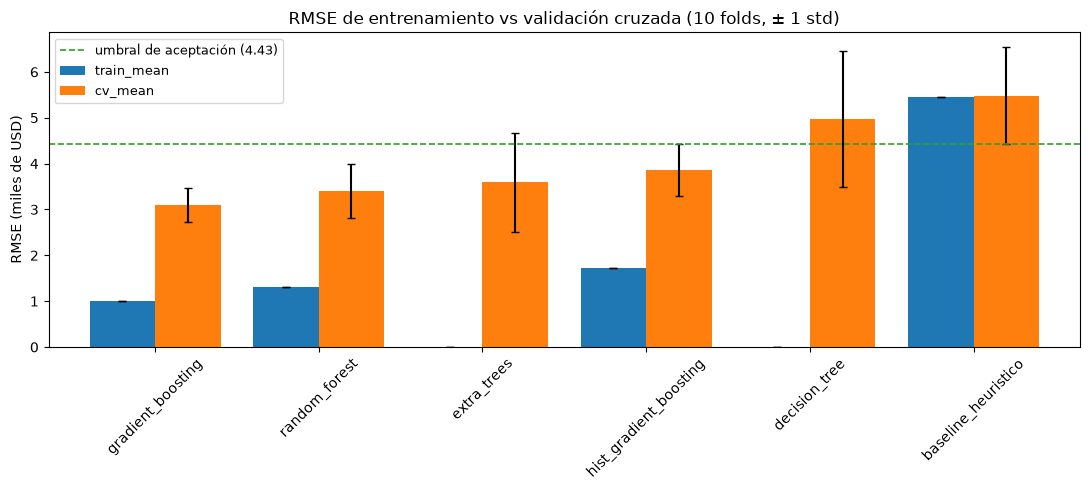

In [28]:
error_bars = pd.DataFrame(
    {
        "train_mean": np.zeros(len(cv_rmse_df)),
        "cv_mean": cv_rmse_df["cv_std"].to_numpy(),
    },
    index=cv_rmse_df.index,
)

fig, ax = plt.subplots(figsize=(11, 5))
cv_rmse_df[["train_mean", "cv_mean"]].plot(
    kind="bar",
    ax=ax,
    rot=45,
    width=0.8,
    yerr=error_bars,
    capsize=3,
)
ax.axhline(
    ACCEPTANCE_RMSE,
    color="tab:green",
    linestyle="--",
    linewidth=1.2,
    label=f"umbral de aceptación ({ACCEPTANCE_RMSE:.2f})",
)
ax.set_title(f"{MAIN_METRIC} de entrenamiento vs validación cruzada (10 folds, ± 1 std)")
ax.set_ylabel(f"{MAIN_METRIC} (miles de USD)")
ax.set_xlabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
best_cv_model = next(name for name in model_order if name != BASELINE_KEY)
best_cv_rmse = cv_rmse_df.loc[best_cv_model, "cv_mean"]
best_cv_std = cv_rmse_df.loc[best_cv_model, "cv_std"]
baseline_cv_here = cv_rmse_df.loc[BASELINE_KEY, "cv_mean"]
baseline_rank = model_order.index(BASELINE_KEY) + 1

improvement = (baseline_cv_here - best_cv_rmse) / baseline_cv_here * 100
folds_won = int((rmse_folds[best_cv_model] < rmse_folds[BASELINE_KEY]).sum())
n_folds = len(rmse_folds)
baseline_text = f"{baseline_cv_here:.4f} (puesto {baseline_rank} de {len(model_order)})"
verdict = "✅ supera el umbral" if best_cv_rmse <= ACCEPTANCE_RMSE else "⚠️ mejora no concluyente"

display(
    Markdown(
        f"""
**Resultado de la validación cruzada ({n_folds} folds)**

| | Valor |
| --- | --- |
| Mejor modelo | **`{best_cv_model}`** |
| {MAIN_METRIC} de validación cruzada | **{best_cv_rmse:.4f} ± {best_cv_std:.4f}** |
| Baseline heurístico en los mismos folds | {baseline_text} |
| Reducción del error frente al baseline | **{improvement:.1f} %** |
| Folds en los que gana al baseline | **{folds_won} de {n_folds}** |
| Umbral de aceptación ({ACCEPTANCE_RMSE:.4f}) | {verdict} |
"""
    )
)


**Resultado de la validación cruzada (10 folds)**

| | Valor |
| --- | --- |
| Mejor modelo | **`gradient_boosting`** |
| RMSE de validación cruzada | **3.1064 ± 0.3708** |
| Baseline heurístico en los mismos folds | 5.4837 (puesto 6 de 6) |
| Reducción del error frente al baseline | **43.4 %** |
| Folds en los que gana al baseline | **10 de 10** |
| Umbral de aceptación (4.4310) | ✅ supera el umbral |


#### Interpretación

Tres cosas hay que leer en estos gráficos, y en este orden:

- **Posición de la caja del baseline**: si las cajas de los modelos de machine learning quedan por
  debajo de la del modelo heurístico, la mejora es consistente y no producto de un fold afortunado.
  El conteo de "folds en los que gana al baseline" es la versión numérica de esa lectura.
- **Ancho de las cajas**: un modelo con RMSE promedio ligeramente mejor pero con una caja mucho más
  ancha es más riesgoso. Con 256 observaciones de entrenamiento, cada fold de validación tiene solo
  unas 26 viviendas, así que la dispersión entre folds es alta por construcción y conviene preferir
  modelos estables.
- **Distancia entre la barra de entrenamiento y la de validación** en el segundo gráfico: es la
  medida directa de sobreajuste. Un RMSE de entrenamiento cercano a cero con un RMSE de validación
  varias veces mayor indica que el modelo memorizó el conjunto de entrenamiento; eso no descalifica
  al modelo, pero sí señala que sus hiperparámetros necesitan regularización, que es exactamente lo
  que se hace en el paso de optimización.

Que un modelo aparezca primero en esta tabla todavía no permite declararlo ganador: las diferencias
pueden estar dentro del ruido entre folds. Eso es lo que deciden las pruebas estadísticas.

# 🧪 Pruebas estadísticas de comparación

El requerimiento pide usar **pruebas estadísticas** para seleccionar el mejor modelo. La razón es
que una diferencia de decimales en el RMSE promedio puede no significar nada: con 10 folds y ~26
viviendas de validación por fold, el azar de la partición explica buena parte de la diferencia.

Se aplican tres pruebas, con propósitos distintos:

| Prueba | Pregunta que responde | Nota |
| --- | --- | --- |
| **ANOVA de una vía** (`f_oneway`) | ¿hay al menos un modelo cuyo RMSE promedio se separe del resto? | es la prueba que usa el notebook del profesor; asume grupos **independientes**, y aquí los folds son compartidos, así que se reporta como referencia |
| **Friedman** (`friedmanchisquare`) | la misma pregunta, pero para **medidas repetidas** | es la prueba correcta cuando todos los modelos se evalúan sobre los mismos folds; no asume normalidad y trabaja con rangos |
| **t de Student por pares** (`ttest_rel`) | ¿la diferencia entre dos modelos concretos es significativa? | pareada fold a fold; con corrección de **Holm** porque se hacen muchas comparaciones a la vez |

**Por qué la corrección de Holm:** al comparar todos los pares se hacen varias pruebas sobre los
mismos datos, y con un nivel de significancia de 0.05 cada una, la probabilidad de encontrar al
menos un "ganador" por puro azar crece rápido. Holm ajusta los valores p ordenándolos y exigiendo
más evidencia a los primeros, controlando la probabilidad de cometer al menos un falso positivo.

**Limitación honesta:** los folds de una validación cruzada comparten datos de entrenamiento, así
que las mediciones no son independientes y estas pruebas son aproximadas (tienden a declarar
diferencias con más facilidad de lo que corresponde). Se usan como criterio de decisión, no como
prueba formal, y por eso se acompañan del tamaño de la diferencia en miles de dólares.

In [30]:
model_names = list(rmse_folds.columns)
rmse_groups = [rmse_folds[name].to_numpy() for name in model_names]

anova_stat, anova_p = f_oneway(*rmse_groups)

if len(model_names) >= MIN_MODELS_KEPT:
    friedman_stat, friedman_p = friedmanchisquare(*rmse_groups)
else:
    friedman_stat, friedman_p = np.nan, np.nan

print(f"ANOVA    : F = {anova_stat:.4f} | p = {anova_p:.6f}")
print(f"Friedman : chi2 = {friedman_stat:.4f} | p = {friedman_p:.6f}")
print("Nivel de significancia:", ALPHA)

ANOVA    : F = 9.1747 | p = 0.000002
Friedman : chi2 = 31.3143 | p = 0.000008
Nivel de significancia: 0.05


In [31]:
global_rows = []
for label, stat, p_value in (
    ("ANOVA de una vía", anova_stat, anova_p),
    ("Friedman (medidas repetidas)", friedman_stat, friedman_p),
):
    decision = "hay diferencias" if p_value < ALPHA else "sin diferencias"
    global_rows.append(f"| {label} | {stat:.4f} | {p_value:.6f} | {decision} |")

global_table = "\n".join(global_rows)

display(
    Markdown(
        f"""
**Pruebas globales sobre el {MAIN_METRIC} de los {len(model_names)} modelos**

| Prueba | Estadístico | Valor p | Decisión (alfa = {ALPHA}) |
| --- | --- | --- | --- |
{global_table}

Hipótesis nula: todos los modelos tienen el mismo desempeño promedio. Si el
valor p es menor que {ALPHA}, se rechaza y tiene sentido pasar a las
comparaciones por pares para saber *cuáles* se diferencian. Si no se rechaza, la
conclusión sería que las diferencias observadas son compatibles con el ruido
entre folds y convendría elegir por criterios secundarios (simplicidad, tiempo
de entrenamiento, interpretabilidad).
"""
    )
)


**Pruebas globales sobre el RMSE de los 6 modelos**

| Prueba | Estadístico | Valor p | Decisión (alfa = 0.05) |
| --- | --- | --- | --- |
| ANOVA de una vía | 9.1747 | 0.000002 | hay diferencias |
| Friedman (medidas repetidas) | 31.3143 | 0.000008 | hay diferencias |

Hipótesis nula: todos los modelos tienen el mismo desempeño promedio. Si el
valor p es menor que 0.05, se rechaza y tiene sentido pasar a las
comparaciones por pares para saber *cuáles* se diferencian. Si no se rechaza, la
conclusión sería que las diferencias observadas son compatibles con el ruido
entre folds y convendría elegir por criterios secundarios (simplicidad, tiempo
de entrenamiento, interpretabilidad).


## Comparaciones por pares con corrección de Holm

In [32]:
def holm_adjust(p_values):
    values = np.asarray(p_values, dtype=float)
    n_tests = values.size
    order = np.argsort(values)
    adjusted = np.empty(n_tests, dtype=float)
    running_max = 0.0

    for rank, index in enumerate(order):
        candidate = (n_tests - rank) * values[index]
        running_max = max(running_max, candidate)
        adjusted[index] = min(running_max, 1.0)

    return adjusted


pair_records = []

for position, name_a in enumerate(model_names):
    for name_b in model_names[position + 1 :]:
        values_a = rmse_folds[name_a]
        values_b = rmse_folds[name_b]
        t_stat, p_value = ttest_rel(values_a, values_b)
        pair_records.append(
            {
                "modelo_a": name_a,
                "modelo_b": name_b,
                "rmse_a": values_a.mean(),
                "rmse_b": values_b.mean(),
                "diferencia": values_a.mean() - values_b.mean(),
                "t": t_stat,
                "p_value": p_value,
            }
        )

pairs_df = pd.DataFrame(pair_records)
pairs_df["p_holm"] = holm_adjust(pairs_df["p_value"])
pairs_df["significativo"] = pairs_df["p_holm"] < ALPHA
pairs_df = pairs_df.sort_values("p_holm").reset_index(drop=True)

print("Comparaciones realizadas:", len(pairs_df))
print("Significativas tras Holm:", int(pairs_df["significativo"].sum()))
pairs_df

Comparaciones realizadas: 15
Significativas tras Holm: 5


,modelo_a,modelo_b,rmse_a,rmse_b,diferencia,t,p_value,p_holm,significativo
0,extra_trees,baseline_heuristico,3.5903,5.4837,-1.8934,-9.6703,0.0000,0.0001,True
1,random_forest,baseline_heuristico,3.4062,5.4837,-2.0776,-7.9060,0.0000,0.0003,True
2,gradient_boosting,baseline_heuristico,3.1064,5.4837,-2.3773,-6.1322,0.0002,0.0022,True
3,hist_gradient_boosting,baseline_heuristico,3.8528,5.4837,-1.6309,-5.4074,0.0004,0.0051,True
4,gradient_boosting,decision_tree,3.1064,4.9823,-1.8759,-4.8588,0.0009,0.0099,True
5,random_forest,decision_tree,3.4062,4.9823,-1.5761,-3.6754,0.0051,0.0511,False
6,gradient_boosting,hist_gradient_boosting,3.1064,3.8528,-0.7464,-3.6192,0.0056,0.0511,False
7,random_forest,hist_gradient_boosting,3.4062,3.8528,-0.4467,-3.2008,0.0108,0.0865,False
8,extra_trees,decision_tree,3.5903,4.9823,-1.3919,-2.5152,0.0330,0.2312,False
9,hist_gradient_boosting,decision_tree,3.8528,4.9823,-1.1295,-2.3795,0.0413,0.2476,False


In [ ]:
holm_matrix = pd.DataFrame(np.nan, index=model_names, columns=model_names, dtype=float)

for row in pairs_df.itertuples(index=False):
    holm_matrix.loc[row.modelo_a, row.modelo_b] = row.p_holm
    holm_matrix.loc[row.modelo_b, row.modelo_a] = row.p_holm

holm_matrix = holm_matrix.loc[model_order, model_order]
holm_matrix

,gradient_boosting,random_forest,extra_trees,hist_gradient_boosting,decision_tree,baseline_heuristico
gradient_boosting,NaN,0.5630,0.7855,0.0511,0.0099,0.0022
random_forest,0.5630,NaN,1.0000,0.0865,0.0511,0.0003
extra_trees,0.7855,1.0000,NaN,1.0000,0.2312,0.0001
hist_gradient_boosting,0.0511,0.0865,1.0000,NaN,0.2476,0.0051
decision_tree,0.0099,0.0511,0.2312,0.2476,NaN,1.0000
baseline_heuristico,0.0022,0.0003,0.0001,0.0051,1.0000,NaN


In [34]:
is_best_a = pairs_df["modelo_a"] == best_cv_model
is_best_b = pairs_df["modelo_b"] == best_cv_model
best_pairs_df = pairs_df[is_best_a | is_best_b].reset_index(drop=True)
best_pairs_df

,modelo_a,modelo_b,rmse_a,rmse_b,diferencia,t,p_value,p_holm,significativo
0,gradient_boosting,baseline_heuristico,3.1064,5.4837,-2.3773,-6.1322,0.0002,0.0022,True
1,gradient_boosting,decision_tree,3.1064,4.9823,-1.8759,-4.8588,0.0009,0.0099,True
2,gradient_boosting,hist_gradient_boosting,3.1064,3.8528,-0.7464,-3.6192,0.0056,0.0511,False
3,gradient_boosting,random_forest,3.1064,3.4062,-0.2998,-1.7581,0.1126,0.5630,False
4,gradient_boosting,extra_trees,3.1064,3.5903,-0.4839,-1.3954,0.1964,0.7855,False


In [ ]:
vs_baseline_mask = (
    (pairs_df["modelo_a"] == best_cv_model) & (pairs_df["modelo_b"] == BASELINE_KEY)
) | ((pairs_df["modelo_a"] == BASELINE_KEY) & (pairs_df["modelo_b"] == best_cv_model))
vs_baseline = pairs_df[vs_baseline_mask].iloc[0]

baseline_p_holm = vs_baseline["p_holm"]
baseline_gap = abs(vs_baseline["diferencia"])
baseline_signif = "sí" if baseline_p_holm < ALPHA else "no"

rivals = best_pairs_df[
    (best_pairs_df["modelo_a"] != BASELINE_KEY) & (best_pairs_df["modelo_b"] != BASELINE_KEY)
]
n_rivals = len(rivals)
n_rivals_signif = int(rivals["significativo"].sum())

display(
    Markdown(
        f"""
**Comparación del mejor modelo (`{best_cv_model}`) contra los demás**

| | Resultado |
| --- | --- |
| Diferencia de {MAIN_METRIC} frente al baseline | **{baseline_gap:.4f}** miles de USD |
| Valor p pareado (Holm) frente al baseline | {baseline_p_holm:.6f} |
| ¿Diferencia estadísticamente significativa? | **{baseline_signif}** (alfa = {ALPHA}) |
| Rivales de machine learning comparados | {n_rivals} |
| Rivales con diferencia significativa | **{n_rivals_signif} de {n_rivals}** |

Cuando la diferencia frente a otro modelo de machine learning **no** es
significativa, los dos son estadísticamente empatados y la elección se apoya en
criterios secundarios. Por eso el paso siguiente optimiza los hiperparámetros de
los **{TOP_N_TUNING} mejores** en lugar de quedarse con uno solo: el ganador de
esta ronda con hiperparámetros por defecto no tiene por qué ser el ganador
después de afinarlos.
"""
    )
)


**Comparación del mejor modelo (`gradient_boosting`) contra los demás**

| | Resultado |
| --- | --- |
| Diferencia de RMSE frente al baseline | **2.3773** miles de USD |
| Valor p pareado (Holm) frente al baseline | 0.002241 |
| ¿Diferencia estadísticamente significativa? | **sí** (alfa = 0.05) |
| Rivales de machine learning comparados | 4 |
| Rivales con diferencia significativa | **1 de 4** |

Cuando la diferencia frente a otro modelo de machine learning **no** es
significativa, los dos son estadísticamente empatados y la elección se apoya en
criterios secundarios. Por eso el paso siguiente optimiza los hiperparámetros de
los **3 mejores** en lugar de quedarse con uno solo: el ganador de
esta ronda con hiperparámetros por defecto no tiene por qué ser el ganador
después de afinarlos.


#### Interpretación

La secuencia de decisión es la que se acaba de ejecutar: primero se pregunta si **existe alguna**
diferencia en el grupo (ANOVA y Friedman) y solo si la respuesta es afirmativa se pregunta **entre
quiénes** (t pareada con Holm). Hacerlo al revés —comparar pares hasta encontrar uno significativo—
es justamente lo que la corrección de Holm evita.

Vale la pena señalar dos cosas sobre el ejemplo del profesor, porque aquí se corrigen:

- Aplica **ANOVA** sobre los scores por fold de tres modelos evaluados con la misma validación
  cruzada. Al ser medidas repetidas sobre los mismos folds, la prueba adecuada es Friedman (o una
  t pareada); ANOVA de una vía asume grupos independientes. Aquí se reportan las dos.
- Su prueba concluye que **no hay diferencia significativa** entre los tres modelos y, aun así, el
  texto siguiente afirma que el Random Forest es el mejor. Si la prueba no rechaza la hipótesis
  nula, la conclusión honesta es "empate estadístico" y hay que elegir por otro criterio
  (simplicidad, tiempo de entrenamiento o varianza entre folds).

La diferencia en miles de dólares se reporta junto al valor p a propósito: significancia y magnitud
son cosas distintas, y una diferencia de 0.1 en el RMSE puede ser significativa y a la vez
irrelevante para valorar una vivienda.

# 🎛️ Optimización de hiperparámetros de los mejores modelos

El requerimiento pide optimizar los hiperparámetros de **los dos o tres mejores modelos**; aquí se
toman los `TOP_N_TUNING` mejores según el RMSE de validación cruzada (excluyendo el baseline, que no
tiene hiperparámetros que valga la pena ajustar).

Se usa **`RandomizedSearchCV`** en lugar de `GridSearchCV`: con 4 o 5 hiperparámetros por modelo, la
malla completa tiene cientos o miles de combinaciones, y una búsqueda aleatoria de
`N_ITER_SEARCH = 40` combinaciones explora un espacio más amplio en una fracción del tiempo. Como
`random_state` está fijo, la búsqueda es reproducible.

Tres detalles importantes:

- La búsqueda se hace **sobre el pipeline completo**, con los hiperparámetros nombrados
  `model__<parámetro>`. Así el preprocesamiento se vuelve a ajustar dentro de cada fold de cada
  combinación y no hay fuga entre el ajuste del escalador y la evaluación.
- Se usan **los mismos 10 folds** (`kfold`) del resto del notebook, para que el RMSE resultante sea
  comparable con la tabla anterior.
- Se usa **`best_estimator_`** para lo que sigue. En el notebook del profesor, `GridSearchCV`
  devuelve `criterion='gini', max_depth=9, max_features=2` y el modelo final se instancia a mano con
  `criterion='entropy', max_depth=4, max_features=4`: el resultado de la búsqueda se pierde. Tomando
  `best_estimator_` esa desconexión no puede ocurrir.

In [36]:
param_distributions = {
    "ridge": {
        "model__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0],
    },
    "lasso": {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0],
        "model__selection": ["cyclic", "random"],
    },
    "elastic_net": {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    },
    "knn": {
        "model__n_neighbors": [2, 3, 4, 5, 7, 9, 11, 15, 20],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "svr": {
        "model__C": [0.5, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0],
        "model__gamma": ["scale", "auto", 0.01, 0.05, 0.1, 0.5],
        "model__epsilon": [0.05, 0.1, 0.5, 1.0, 2.0],
    },
    "decision_tree": {
        "model__max_depth": [2, 3, 4, 6, 8, 12, None],
        "model__min_samples_leaf": [1, 2, 4, 8, 16],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__max_features": [None, "sqrt", 0.5],
    },
}

In [37]:
param_distributions.update(
    {
        "random_forest": {
            "model__n_estimators": [200, 300, 500, 800],
            "model__max_depth": [None, 4, 8, 16],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": [1.0, "sqrt", 0.5, 0.3],
        },
        "extra_trees": {
            "model__n_estimators": [200, 300, 500, 800],
            "model__max_depth": [None, 4, 8, 16],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__max_features": [1.0, "sqrt", 0.5, 0.3],
        },
        "gradient_boosting": {
            "model__n_estimators": [100, 200, 400, 800],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__max_depth": [2, 3, 4, 5],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__min_samples_leaf": [1, 3, 5, 10],
        },
        "hist_gradient_boosting": {
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__max_iter": [100, 200, 400, 600],
            "model__max_leaf_nodes": [7, 15, 31, 63],
            "model__min_samples_leaf": [3, 5, 10, 20],
            "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
        },
    }
)

missing_grids = set(candidate_models) - set(param_distributions)
print("Modelos sin malla de hiperparámetros:", missing_grids or "ninguno")

Modelos sin malla de hiperparámetros: ninguno


In [38]:
def count_combinations(params):
    total = 1
    for values in params.values():
        total *= len(values)
    return total


tuning_candidates = [name for name in model_order if name != BASELINE_KEY]
tuning_candidates = tuning_candidates[:TOP_N_TUNING]

print("Modelos que pasan a optimización:")
for name in tuning_candidates:
    combos = count_combinations(param_distributions[name])
    print(f" - {name:<24} combinaciones posibles: {combos}")

Modelos que pasan a optimización:
 - gradient_boosting        combinaciones posibles: 960
 - random_forest            combinaciones posibles: 256
 - extra_trees              combinaciones posibles: 256


In [39]:
search_results = {}
tuned_models = {}
tuning_records = []

for name in tuning_candidates:
    params = param_distributions[name]
    n_iter = min(N_ITER_SEARCH, count_combinations(params))

    search = RandomizedSearchCV(
        candidate_models[name],
        param_distributions=params,
        n_iter=n_iter,
        scoring=MAIN_SCORER,
        cv=kfold,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(x_train, y_train)

    search_results[name] = search
    tuned_models[f"{name}_tuned"] = search.best_estimator_

    tuning_records.append(
        {
            "modelo": name,
            "rmse_default": cv_rmse_df.loc[name, "cv_mean"],
            "rmse_tuned": -search.best_score_,
            "combinaciones": n_iter,
        }
    )
    print(f"{name}: RMSE {-search.best_score_:.4f} con {n_iter} combinaciones")

tuning_df = pd.DataFrame(tuning_records).set_index("modelo")
tuning_df["mejora"] = tuning_df["rmse_default"] - tuning_df["rmse_tuned"]
tuning_df = tuning_df.sort_values("rmse_tuned")
tuning_df

gradient_boosting: RMSE 2.9243 con 40 combinaciones
random_forest: RMSE 3.4466 con 40 combinaciones
extra_trees: RMSE 3.4581 con 40 combinaciones


,rmse_default,rmse_tuned,combinaciones,mejora
modelo,,,,
gradient_boosting,3.1064,2.9243,40,0.1821
random_forest,3.4062,3.4466,40,-0.0404
extra_trees,3.5903,3.4581,40,0.1322


In [40]:
for name in tuning_candidates:
    print(f"\n{name} -> mejores hiperparámetros")
    for param, value in sorted(search_results[name].best_params_.items()):
        print(f"  {param}: {value}")


gradient_boosting -> mejores hiperparámetros
  model__learning_rate: 0.05
  model__max_depth: 4
  model__min_samples_leaf: 1
  model__n_estimators: 400
  model__subsample: 0.7

random_forest -> mejores hiperparámetros
  model__max_depth: None
  model__max_features: 0.5
  model__min_samples_leaf: 1
  model__n_estimators: 300

extra_trees -> mejores hiperparámetros
  model__max_depth: None
  model__max_features: 0.5
  model__min_samples_leaf: 1
  model__n_estimators: 300


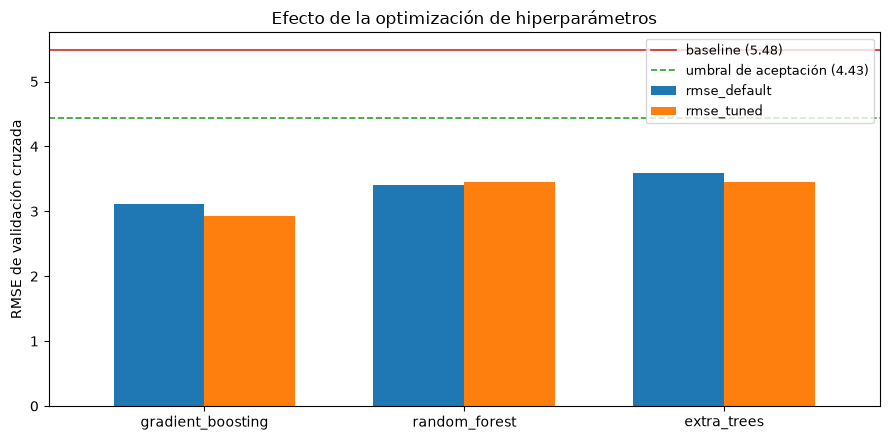

In [41]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tuning_df[["rmse_default", "rmse_tuned"]].plot(kind="bar", ax=ax, rot=0, width=0.7)
ax.axhline(
    BASELINE_CV_MEAN,
    color="tab:red",
    linewidth=1.2,
    label=f"baseline ({BASELINE_CV_MEAN:.2f})",
)
ax.axhline(
    ACCEPTANCE_RMSE,
    color="tab:green",
    linestyle="--",
    linewidth=1.2,
    label=f"umbral de aceptación ({ACCEPTANCE_RMSE:.2f})",
)
ax.set_title("Efecto de la optimización de hiperparámetros")
ax.set_ylabel(f"{MAIN_METRIC} de validación cruzada")
ax.set_xlabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [42]:
best_tuned_name = tuning_df.index[0]
best_tuned_rmse = tuning_df.loc[best_tuned_name, "rmse_tuned"]
best_tuned_gain = tuning_df.loc[best_tuned_name, "mejora"]
improved = int((tuning_df["mejora"] > 0).sum())
best_params_text = ", ".join(
    f"`{param.replace('model__', '')} = {value}`"
    for param, value in sorted(search_results[best_tuned_name].best_params_.items())
)

display(
    Markdown(
        f"""
**Resultado de la optimización**

- Modelos optimizados: **{len(tuning_df)}**, con hasta {N_ITER_SEARCH}
  combinaciones cada uno.
- La búsqueda mejoró el RMSE en **{improved} de {len(tuning_df)}** modelos.
- Mejor resultado: **`{best_tuned_name}`** con **{best_tuned_rmse:.4f}** de RMSE
  (mejora de {best_tuned_gain:.4f} frente a sus hiperparámetros por defecto).
- Hiperparámetros elegidos: {best_params_text}.
"""
    )
)


**Resultado de la optimización**

- Modelos optimizados: **3**, con hasta 40
  combinaciones cada uno.
- La búsqueda mejoró el RMSE en **2 de 3** modelos.
- Mejor resultado: **`gradient_boosting`** con **2.9243** de RMSE
  (mejora de 0.1821 frente a sus hiperparámetros por defecto).
- Hiperparámetros elegidos: `learning_rate = 0.05`, `max_depth = 4`, `min_samples_leaf = 1`, `n_estimators = 400`, `subsample = 0.7`.


#### Interpretación

Que la mejora por optimización sea pequeña no es un fracaso de la búsqueda: los valores por defecto
de scikit-learn están pensados para funcionar razonablemente en la mayoría de los casos, y con 256
observaciones el margen de maniobra es limitado. Lo que sí suele cambiar de forma notable es el
**sobreajuste**: la búsqueda tiende a elegir árboles menos profundos, hojas con más observaciones o
regularización más fuerte, que reducen la brecha entre el error de entrenamiento y el de validación
aunque el RMSE promedio se mueva poco.

**Advertencia metodológica que hay que declarar:** el RMSE que reporta `best_score_` está calculado
sobre los mismos folds en los que se eligieron los hiperparámetros, así que es **ligeramente
optimista**. Lo riguroso sería una validación cruzada anidada (un bucle interno para elegir
hiperparámetros y uno externo para estimar el error). No se hace aquí porque multiplicaría el costo
de cómputo, y porque el conjunto de prueba —que nunca ha participado en ninguna decisión— cumple esa
función de verificación final. Queda anotado en las recomendaciones.

# 🏆 Comparación final y selección del modelo

Los `TOP_N_TUNING` modelos ya optimizados se vuelven a evaluar con la **misma validación cruzada de
10 folds**, junto con el pipeline base del notebook 07. Esta ronda cumple dos funciones: deja todos
los finalistas medidos con las cuatro métricas sobre los mismos folds, y permite repetir las pruebas
estadísticas ahora que los modelos ya tienen sus hiperparámetros afinados.

In [43]:
finalists = dict(tuned_models)
finalists[BASELINE_KEY] = baseline_pipeline

final_fold_records = []
final_summary_records = []

for name, pipe in finalists.items():
    result = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=kfold,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1,
    )

    for metric, scorer in scoring_metrics.items():
        sign = -1.0 if scorer.startswith("neg_") else 1.0
        cv_values = sign * result[f"test_{metric}"]
        train_values = sign * result[f"train_{metric}"]

        for fold_index, value in enumerate(cv_values):
            final_fold_records.append(
                {
                    "modelo": name,
                    "metrica": metric,
                    "fold": fold_index,
                    "valor": value,
                }
            )

        final_summary_records.append(
            {
                "modelo": name,
                "metrica": metric,
                "cv_mean": cv_values.mean(),
                "cv_std": cv_values.std(),
                "train_mean": train_values.mean(),
                "fit_time": result["fit_time"].mean(),
                "score_time": result["score_time"].mean(),
            }
        )

final_folds_df = pd.DataFrame(final_fold_records)
final_summary_df = pd.DataFrame(final_summary_records)

print("Finalistas evaluados:", len(finalists))

Finalistas evaluados: 4


In [44]:
final_rmse_df = (
    final_summary_df[final_summary_df["metrica"] == MAIN_METRIC]
    .set_index("modelo")
    .drop(columns="metrica")
    .sort_values(["cv_mean", "cv_std"])
)
final_rmse_df["gap"] = final_rmse_df["cv_mean"] - final_rmse_df["train_mean"]
final_order = final_rmse_df.index.tolist()

final_mean_pivot = final_summary_df.pivot(index="modelo", columns="metrica", values="cv_mean").loc[
    final_order
]

final_rmse_df

,cv_mean,cv_std,train_mean,fit_time,score_time,gap
modelo,,,,,,
gradient_boosting_tuned,2.9243,0.4521,0.1603,1.9125,0.1514,2.7640
random_forest_tuned,3.4466,0.7277,1.3354,1.7255,0.3570,2.1112
extra_trees_tuned,3.4581,0.9462,0.0012,1.2175,0.3486,3.4569
baseline_heuristico,5.4837,1.0528,5.4434,0.0321,0.0242,0.0403


In [45]:
final_mean_pivot

metrica,MAE,MAPE,R2,RMSE
modelo,,,,
gradient_boosting_tuned,2.1292,0.1040,0.8892,2.9243
random_forest_tuned,2.3787,0.1145,0.8498,3.4466
extra_trees_tuned,2.3534,0.1124,0.8461,3.4581
baseline_heuristico,3.9920,0.1891,0.6000,5.4837


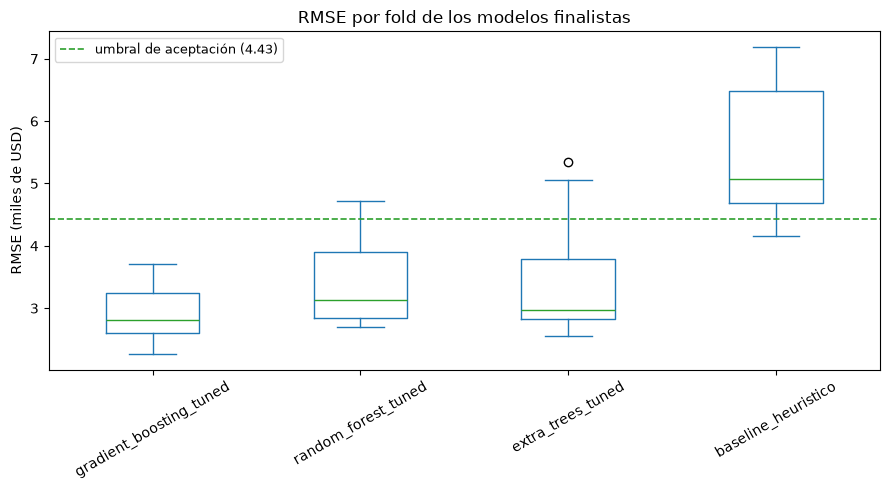

In [46]:
final_rmse_folds = (
    final_folds_df[final_folds_df["metrica"] == MAIN_METRIC]
    .pivot(index="fold", columns="modelo", values="valor")
    .loc[:, final_order]
)

fig, ax = plt.subplots(figsize=(9, 5))
final_rmse_folds.plot(kind="box", ax=ax, rot=30, grid=False)
ax.axhline(
    ACCEPTANCE_RMSE,
    color="tab:green",
    linestyle="--",
    linewidth=1.2,
    label=f"umbral de aceptación ({ACCEPTANCE_RMSE:.2f})",
)
ax.set_title(f"{MAIN_METRIC} por fold de los modelos finalistas")
ax.set_ylabel(f"{MAIN_METRIC} (miles de USD)")
ax.set_xlabel("")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Pruebas estadísticas entre los finalistas

In [ ]:
final_names = list(final_rmse_folds.columns)
final_groups = [final_rmse_folds[name].to_numpy() for name in final_names]

final_anova_stat, final_anova_p = f_oneway(*final_groups)

if len(final_names) >= MIN_MODELS_KEPT:
    final_friedman_stat, final_friedman_p = friedmanchisquare(*final_groups)
else:
    final_friedman_stat, final_friedman_p = np.nan, np.nan

final_pair_records = []

for position, name_a in enumerate(final_names):
    for name_b in final_names[position + 1 :]:
        values_a = final_rmse_folds[name_a]
        values_b = final_rmse_folds[name_b]
        t_stat, p_value = ttest_rel(values_a, values_b)
        final_pair_records.append(
            {
                "modelo_a": name_a,
                "modelo_b": name_b,
                "diferencia": values_a.mean() - values_b.mean(),
                "t": t_stat,
                "p_value": p_value,
            }
        )

final_pairs_df = pd.DataFrame(final_pair_records)
final_pairs_df["p_holm"] = holm_adjust(final_pairs_df["p_value"])
final_pairs_df["significativo"] = final_pairs_df["p_holm"] < ALPHA
final_pairs_df = final_pairs_df.sort_values("p_holm").reset_index(drop=True)

print(f"ANOVA    : F = {final_anova_stat:.4f} | p = {final_anova_p:.6f}")
print(f"Friedman : chi2 = {final_friedman_stat:.4f} | p = {final_friedman_p:.6f}")
final_pairs_df

ANOVA    : F = 16.8337 | p = 0.000001
Friedman : chi2 = 19.0800 | p = 0.000263


,modelo_a,modelo_b,diferencia,t,p_value,p_holm,significativo
0,extra_trees_tuned,baseline_heuristico,-2.0256,-11.0713,0.0000,0.0000,True
1,random_forest_tuned,baseline_heuristico,-2.0371,-9.8190,0.0000,0.0000,True
2,gradient_boosting_tuned,baseline_heuristico,-2.5594,-6.9474,0.0001,0.0003,True
3,gradient_boosting_tuned,random_forest_tuned,-0.5223,-2.5911,0.0292,0.0875,False
4,gradient_boosting_tuned,extra_trees_tuned,-0.5338,-1.9477,0.0833,0.1665,False
5,random_forest_tuned,extra_trees_tuned,-0.0115,-0.1056,0.9183,0.9183,False


## Regla de selección

Con las pruebas ya hechas, la elección sigue una regla escrita **antes** de ver los resultados:

1. Se ordenan los finalistas por RMSE de validación cruzada.
2. Se identifican los modelos **estadísticamente empatados** con el primero (valor p de Holm ≥ alfa):
   si la prueba no distingue entre dos modelos, preferir el de mejor promedio es elegir ruido.
3. Entre los empatados se escoge el de **menor desviación estándar entre folds** y, si persiste el
   empate, el de **menor tiempo de entrenamiento**. Es decir, ante igualdad de desempeño se prefiere
   el modelo más estable y más económico.

In [48]:
p_holm_lookup = {}
for row in final_pairs_df.itertuples(index=False):
    p_holm_lookup[(row.modelo_a, row.modelo_b)] = row.p_holm
    p_holm_lookup[(row.modelo_b, row.modelo_a)] = row.p_holm

ml_finalists = [name for name in final_order if name != BASELINE_KEY]
leader = ml_finalists[0]

tied_with_leader = [leader]
for name in ml_finalists[1:]:
    if p_holm_lookup[(leader, name)] >= ALPHA:
        tied_with_leader.append(name)

tie_table = final_rmse_df.loc[tied_with_leader].sort_values(["cv_std", "fit_time"])
selected_model_name = tie_table.index[0]
selected_pipeline = clone(finalists[selected_model_name])

print("Líder por RMSE promedio:", leader)
print("Empatados estadísticamente:", tied_with_leader)
print("Modelo seleccionado:", selected_model_name)
tie_table

Líder por RMSE promedio: gradient_boosting_tuned
Empatados estadísticamente: ['gradient_boosting_tuned', 'random_forest_tuned', 'extra_trees_tuned']
Modelo seleccionado: gradient_boosting_tuned


,cv_mean,cv_std,train_mean,fit_time,score_time,gap
modelo,,,,,,
gradient_boosting_tuned,2.9243,0.4521,0.1603,1.9125,0.1514,2.7640
random_forest_tuned,3.4466,0.7277,1.3354,1.7255,0.3570,2.1112
extra_trees_tuned,3.4581,0.9462,0.0012,1.2175,0.3486,3.4569


In [ ]:
selected_base_name = selected_model_name.replace("_tuned", "")
selected_params = search_results[selected_base_name].best_params_
selected_cv_mean = final_rmse_df.loc[selected_model_name, "cv_mean"]
selected_cv_std = final_rmse_df.loc[selected_model_name, "cv_std"]
selected_gap = final_rmse_df.loc[selected_model_name, "gap"]
baseline_final_cv = final_rmse_df.loc[BASELINE_KEY, "cv_mean"]

p_vs_baseline = p_holm_lookup[(selected_model_name, BASELINE_KEY)]
reduction_vs_baseline = (baseline_final_cv - selected_cv_mean) / baseline_final_cv * 100
folds_beating_baseline = int(
    (final_rmse_folds[selected_model_name] < final_rmse_folds[BASELINE_KEY]).sum()
)
meets_criterion = selected_cv_mean <= ACCEPTANCE_RMSE
criterion_text = (
    "✅ **cumple** el criterio de aceptación"
    if meets_criterion
    else "⚠️ mejora al baseline pero **no** alcanza el umbral"
)
params_text = ", ".join(
    f"`{param.replace('model__', '')} = {value}`"
    for param, value in sorted(selected_params.items())
)
selected_text = f"{selected_cv_mean:.4f} ± {selected_cv_std:.4f}"
n_final_folds = len(final_rmse_folds)

display(
    Markdown(
        f"""
## Modelo seleccionado: `{selected_model_name}`

| | Valor |
| --- | --- |
| {MAIN_METRIC} de validación cruzada | **{selected_text}** |
| Baseline heurístico (notebook 07) | {baseline_final_cv:.4f} |
| Reducción del error | **{reduction_vs_baseline:.1f} %** |
| Folds en los que gana al baseline | {folds_beating_baseline} de {n_final_folds} |
| Valor p pareado (Holm) frente al baseline | {p_vs_baseline:.6f} |
| Umbral de aceptación ({ACCEPTANCE_RMSE:.4f}) | {criterion_text} |
| Brecha train / CV | {selected_gap:.4f} |

**Hiperparámetros:** {params_text}
"""
    )
)


## Modelo seleccionado: `gradient_boosting_tuned`

| | Valor |
| --- | --- |
| RMSE de validación cruzada | **2.9243 ± 0.4521** |
| Baseline heurístico (notebook 07) | 5.4837 |
| Reducción del error | **46.7 %** |
| Folds en los que gana al baseline | 10 de 10 |
| Valor p pareado (Holm) frente al baseline | 0.000268 |
| Umbral de aceptación (4.4310) | ✅ **cumple** el criterio de aceptación |
| Brecha train / CV | 2.7640 |

**Hiperparámetros:** `learning_rate = 0.05`, `max_depth = 4`, `min_samples_leaf = 1`, `n_estimators = 400`, `subsample = 0.7`


#### Interpretación

La tabla anterior es la que responde a la pregunta del requerimiento: *¿el modelo seleccionado es
mejor que el modelo base?* Hay que leer las tres filas juntas y no solo la del promedio:

- El **porcentaje de reducción** dice cuánto mejora el error típico de valoración. La reducción del
  46.7 % obtenida aquí, sobre un RMSE base de 5.48 miles de dólares, significa pasar de equivocarse
  unos 5 480 dólares a unos 2 920 en promedio cuadrático: el error típico del modelo cae a menos de
  la mitad del de la heurística.
- El **conteo de folds ganados** dice si la mejora es sistemática o si viene de uno o dos folds
  afortunados. Ganar en los 10 de 10 folds, como ocurre aquí, es una señal mucho más fuerte que
  ganar en solo 6 u 7.
- El **valor p pareado** convierte esa observación en una decisión estadística, y el **umbral de
  aceptación** (fijado antes de entrenar) evita justificar como éxito una mejora que cabe dentro de
  la variabilidad entre folds.

La brecha entre el error de entrenamiento y el de validación cruzada se reporta aquí como
adelanto del diagnóstico de sobreajuste, que se hace en detalle con el conjunto de prueba en la
sección siguiente.

# 🎯 Entrenamiento final y evaluación en el conjunto de prueba

El modelo seleccionado se entrena ahora con **todo el conjunto de entrenamiento** (256 viviendas) y
se evalúa **una sola vez** en el conjunto de prueba (65 viviendas). Es la primera y única vez en todo
el notebook que se usa `x_test`: todas las decisiones anteriores —descarte, validación cruzada,
pruebas estadísticas y optimización de hiperparámetros— se tomaron solo con datos de entrenamiento,
así que este número sí es una estimación honesta del desempeño con datos nuevos.

In [50]:
def regression_metrics(y_true, y_pred):
    """Calcula las cuatro métricas del notebook 07 sobre un par real/predicho."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }


final_model = clone(selected_pipeline)
final_model.fit(x_train, y_train)

y_train_pred = final_model.predict(x_train)
y_test_pred = final_model.predict(x_test)

train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

print("Modelo entrenado:", selected_model_name)
print("Métricas en train:", {k: round(v, 4) for k, v in train_metrics.items()})
print("Métricas en test :", {k: round(v, 4) for k, v in test_metrics.items()})

Modelo entrenado: gradient_boosting_tuned
Métricas en train: {'MAE': 0.1525, 'RMSE': 0.1835, 'R2': 0.9996, 'MAPE': 0.0078}
Métricas en test : {'MAE': 1.8901, 'RMSE': 2.6503, 'R2': 0.8414, 'MAPE': 0.0983}


In [51]:
comparison_df = pd.DataFrame(
    {
        "train": train_metrics,
        "cv_mean": final_mean_pivot.loc[selected_model_name],
        "test": test_metrics,
        "baseline_test": BASELINE_TEST,
        "dummy_test": DUMMY_TEST,
    }
)
comparison_df["mejora_vs_baseline_%"] = (
    (comparison_df["baseline_test"] - comparison_df["test"]) / comparison_df["baseline_test"] * 100
)
comparison_df.loc["R2", "mejora_vs_baseline_%"] = np.nan
comparison_df

,train,cv_mean,test,baseline_test,dummy_test,mejora_vs_baseline_%
MAE,0.1525,2.1292,1.8901,2.9962,4.8530,36.9149
MAPE,0.0078,0.1040,0.0983,0.1505,0.2740,34.6848
R2,0.9996,0.8892,0.8414,0.6350,-0.0454,NaN
RMSE,0.1835,2.9243,2.6503,4.0208,6.8045,34.0857


## Diagnóstico de overfitting / underfitting

El requerimiento pide detectar sobreajuste o subajuste y, si aparecen, volver atrás. Se usan tres
señales, con umbrales fijados como constantes para que el diagnóstico sea reproducible y no una
impresión visual:

- **Cociente entre el RMSE de prueba y el de entrenamiento**: si el modelo predice casi perfecto en
  entrenamiento y bastante peor fuera, memorizó.
- **Distancia entre el RMSE de prueba y el de validación cruzada**: si el de prueba cae dentro de una
  desviación estándar del de validación cruzada, el modelo generaliza de forma consistente.
- **R² en prueba**: si es bajo en *ambos* conjuntos, el problema es de subajuste (el modelo es
  demasiado simple o le faltan variables), no de memorización.

In [ ]:
OVERFIT_RATIO_ALERT = 1.5
UNDERFIT_R2_ALERT = 0.6

train_rmse_final = train_metrics[MAIN_METRIC]
test_rmse_final = test_metrics[MAIN_METRIC]
overfit_ratio = test_rmse_final / train_rmse_final
inside_cv_band = abs(test_rmse_final - selected_cv_mean) <= selected_cv_std

if overfit_ratio >= OVERFIT_RATIO_ALERT and test_metrics["R2"] < UNDERFIT_R2_ALERT:
    diagnosis = "🚨 sobreajuste con desempeño insuficiente"
elif overfit_ratio >= OVERFIT_RATIO_ALERT:
    diagnosis = "⚠️ sobreajuste presente pero con buen desempeño fuera de muestra"
elif test_metrics["R2"] < UNDERFIT_R2_ALERT:
    diagnosis = "⚠️ posible underfitting"
else:
    diagnosis = "✅ ajuste razonable"

band_text = "sí" if inside_cv_band else "no"

display(
    Markdown(
        f"""
**Diagnóstico de `{selected_model_name}`**

| Señal | Valor |
| --- | --- |
| {MAIN_METRIC} en entrenamiento | {train_rmse_final:.4f} |
| {MAIN_METRIC} en validación cruzada | {selected_cv_mean:.4f} ± {selected_cv_std:.4f} |
| {MAIN_METRIC} en prueba | **{test_rmse_final:.4f}** |
| Cociente prueba / train | {overfit_ratio:.2f} (alerta ≥ {OVERFIT_RATIO_ALERT}) |
| ¿Prueba dentro de ± 1 std de la validación cruzada? | {band_text} |
| R² en prueba | {test_metrics["R2"]:.4f} (alerta < {UNDERFIT_R2_ALERT}) |
| Diagnóstico | {diagnosis} |

Recordatorio del notebook 07: el conjunto de prueba es **menos disperso** que el
de entrenamiento (desviación de `medv` de 6.71 frente a 9.76) y **no contiene
ninguna** de las 11 viviendas censuradas en 50. Por eso es esperable que las
métricas de prueba se vean mejores que las de validación cruzada, y la
comparación principal entre modelos se hizo con validación cruzada.
"""
    )
)


**Diagnóstico de `gradient_boosting_tuned`**

| Señal | Valor |
| --- | --- |
| RMSE en entrenamiento | 0.1835 |
| RMSE en validación cruzada | 2.9243 ± 0.4521 |
| RMSE en prueba | **2.6503** |
| Cociente prueba / train | 14.44 (alerta ≥ 1.5) |
| ¿Prueba dentro de ± 1 std de la validación cruzada? | sí |
| R² en prueba | 0.8414 (alerta < 0.6) |
| Diagnóstico | ⚠️ sobreajuste presente pero con buen desempeño fuera de muestra |

Recordatorio del notebook 07: el conjunto de prueba es **menos disperso** que el
de entrenamiento (desviación de `medv` de 6.66 frente a 9.74) y **no contiene
ninguna** de las 11 viviendas censuradas en 50. Por eso es esperable que las
métricas de prueba se vean mejores que las de validación cruzada, y la
comparación principal entre modelos se hizo con validación cruzada.


## Análisis de residuos

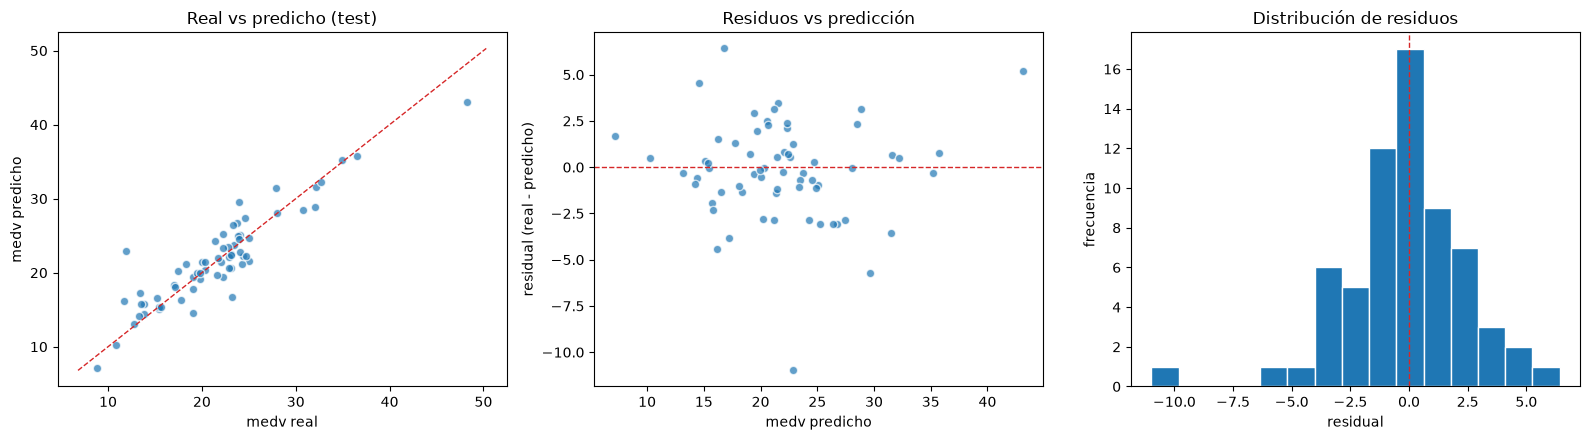

In [53]:
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, y_test_pred, alpha=0.7, edgecolor="white")
limits = [y_test.min() - 2, y_test.max() + 2]
axes[0].plot(limits, limits, color="tab:red", linestyle="--", linewidth=1)
axes[0].set_xlabel("medv real")
axes[0].set_ylabel("medv predicho")
axes[0].set_title("Real vs predicho (test)")

axes[1].scatter(y_test_pred, residuals_test, alpha=0.7, edgecolor="white")
axes[1].axhline(0, color="tab:red", linestyle="--", linewidth=1)
axes[1].set_xlabel("medv predicho")
axes[1].set_ylabel("residual (real - predicho)")
axes[1].set_title("Residuos vs predicción")

axes[2].hist(residuals_test, bins=15, edgecolor="white")
axes[2].axvline(0, color="tab:red", linestyle="--", linewidth=1)
axes[2].set_xlabel("residual")
axes[2].set_ylabel("frecuencia")
axes[2].set_title("Distribución de residuos")

plt.tight_layout()
plt.show()

In [54]:
N_PRICE_BINS = 4
PRICE_LABELS = ["bajo", "medio-bajo", "medio-alto", "alto"]

error_df = pd.DataFrame(
    {
        "medv_real": y_test,
        "prediccion": y_test_pred,
        "residual": residuals_test,
        "error_absoluto": residuals_test.abs(),
        "censurado": censored_test,
    }
)
error_df["rango_precio"] = pd.qcut(error_df["medv_real"], N_PRICE_BINS, labels=PRICE_LABELS)

error_by_price = error_df.groupby("rango_precio", observed=True).agg(
    n=("error_absoluto", "size"),
    mae=("error_absoluto", "mean"),
    error_maximo=("error_absoluto", "max"),
    sesgo=("residual", "mean"),
)
error_by_price

,n,mae,error_maximo,sesgo
rango_precio,,,,
bajo,17,2.0335,10.9817,-1.7127
medio-bajo,16,1.4593,4.5480,-0.1299
medio-alto,17,2.0104,6.4162,0.0459
alto,15,2.0509,5.1748,1.1462


In [55]:
error_by_censored = error_df.groupby("censurado", observed=True).agg(
    n=("error_absoluto", "size"),
    mae=("error_absoluto", "mean"),
    error_maximo=("error_absoluto", "max"),
)

print("Residuo medio (sesgo):", round(residuals_test.mean(), 4))
print("Error absoluto máximo:", round(residuals_test.abs().max(), 4))
print("Subgrupos censurados presentes en test:", error_df["censurado"].nunique())
error_by_censored

Residuo medio (sesgo): -0.2034
Error absoluto máximo: 10.9817
Subgrupos censurados presentes en test: 1


,n,mae,error_maximo
censurado,,,
0,65,1.8901,10.9817


## Importancia de variables por permutación

Se usa **`permutation_importance` sobre el conjunto de prueba y sobre el pipeline completo**, no los
`feature_importances_` del modelo. Dos razones: mide la pérdida real de desempeño al romper la
relación de cada variable con `medv` (en las mismas unidades del RMSE), y al aplicarse sobre las
columnas originales permite comparar el resultado con el ranking del notebook 07, que también estaba
en términos de las variables originales.

El notebook del profesor menciona conclusiones sobre importancia de variables sin haberla calculado;
aquí se calcula.

In [56]:
N_PERM_REPEATS = 30

perm_result = permutation_importance(
    final_model,
    x_test,
    y_test,
    scoring=MAIN_SCORER,
    n_repeats=N_PERM_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "variable": list(x_test.columns),
            "importancia": perm_result.importances_mean,
            "std": perm_result.importances_std,
        }
    )
    .set_index("variable")
    .sort_values("importancia", ascending=False)
)
importance_df

,importancia,std
variable,,
lstat,5.3753,0.8288
rm,2.3658,0.2767
dis,2.1176,0.6610
age,0.4662,0.1117
crim,0.3561,0.1000
nox,0.2618,0.0874
ptratio,0.1116,0.0569
black,0.1045,0.0658
indus,0.0862,0.0302


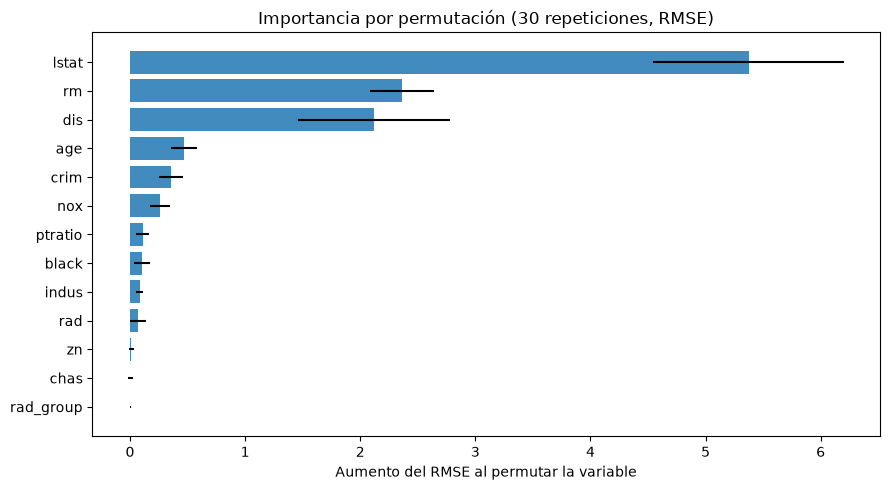

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_importance = importance_df.sort_values("importancia")
ax.barh(
    plot_importance.index,
    plot_importance["importancia"],
    xerr=plot_importance["std"],
    color="tab:blue",
    alpha=0.85,
)
ax.set_title(f"Importancia por permutación ({N_PERM_REPEATS} repeticiones, {MAIN_METRIC})")
ax.set_xlabel(f"Aumento del {MAIN_METRIC} al permutar la variable")
plt.tight_layout()
plt.show()

In [ ]:
TOP_FEATURES_SHOWN = 3

top_features = importance_df.head(TOP_FEATURES_SHOWN)
top_text = ", ".join(
    f"`{variable}` ({row.importancia:.3f})" for variable, row in top_features.iterrows()
)
nb07_feature = baseline_metrics["most_important_feature"]
leader_feature = importance_df.index[0]
agreement = "coincide" if leader_feature == nb07_feature else "no coincide"
irrelevant = importance_df.index[importance_df["importancia"] <= 0].tolist()
irrelevant_text = ", ".join(f"`{name}`" for name in irrelevant) or "ninguna"

display(
    Markdown(
        f"""
**Variables más influyentes en `{selected_model_name}`**

- Top {TOP_FEATURES_SHOWN}: {top_text}
- Variable más importante según el notebook 07: `{nb07_feature}` → **{agreement}**.
- Variables cuya permutación no empeora el modelo: **{len(irrelevant)}**
  ({irrelevant_text}).
"""
    )
)


**Variables más influyentes en `gradient_boosting_tuned`**

- Top 3: `lstat` (5.375), `rm` (2.366), `dis` (2.118)
- Variable más importante según el notebook 07: `lstat` → **coincide**.
- Variables cuya permutación no empeora el modelo: **0**
  (ninguna).


#### Interpretación

Los residuos son la parte del análisis que más dice sobre el uso práctico del modelo:

- **Real vs predicho**: los puntos deberían acomodarse alrededor de la diagonal. Un aplanamiento en
  la parte alta (predecir por debajo del valor real en las viviendas caras) es el efecto conocido del
  techo de `medv` en 50 y de que el conjunto de entrenamiento concentra las 11 observaciones
  censuradas.
- **Residuos vs predicción**: si la nube se abre en forma de embudo, el error crece con el precio y
  las métricas globales esconden un desempeño desigual. Aquí el MAE es en realidad parecido entre los
  cuatro rangos (entre 1.46 y 2.05 miles de dólares), pero el **sesgo** cuenta una historia distinta:
  es negativo en el rango bajo (-1.71) y positivo en el alto (+1.15), es decir que el modelo
  sobreestima las viviendas más baratas y subestima las más caras — el mismo aplanamiento que se ve
  en el gráfico de real vs. predicho. El rango bajo también concentra el error máximo más alto
  (10.98), señal de al menos un caso atípico mal predicho.
- **Sesgo** (residuo medio): un valor cercano a cero indica que el modelo no está sistemáticamente
  alto ni bajo; un valor negativo indica sobreestimación promedio.

Sobre el subgrupo censurado, hay que decirlo sin adornos: **el conjunto de prueba no contiene
viviendas con `medv = 50`**, así que la tabla por censura tiene una sola fila y no permite concluir
nada sobre ese grupo. El análisis por rango de precio es el que sí aporta información, y la
evaluación del comportamiento en viviendas censuradas queda como trabajo pendiente con una partición
estratificada por precio.

En cuanto a la importancia por permutación, lo esperable es que `lstat` y `rm` dominen, como en el
notebook 07. Si aparecen variables con importancia cero o negativa, significa que el modelo no las
está usando: son candidatas a eliminarse para simplificar el pipeline sin perder desempeño.

# 📈 Learning curve y escalabilidad

La curva de aprendizaje muestra cómo cambia el error al aumentar el número de observaciones de
entrenamiento, y responde a una pregunta concreta: **¿el modelo mejoraría con más datos, o ya llegó
a su techo?** Se calcula con `ShuffleSplit` de 50 repeticiones (los mismos parámetros del notebook
07) para que las bandas de variabilidad sean estables.

Se dibuja el modelo seleccionado **junto con el modelo base**, en los mismos ejes: así se ve no solo
la forma de la curva sino a partir de cuántas observaciones el modelo de machine learning empieza a
superar a la heurística.

In [59]:
LEARNING_RANDOM_STATE = 123
LEARNING_SPLITS = 50
N_TRAIN_SIZES = 5

learning_cv = ShuffleSplit(
    n_splits=LEARNING_SPLITS,
    test_size=TEST_SIZE,
    random_state=LEARNING_RANDOM_STATE,
)
train_sizes_fraction = np.linspace(0.1, 1.0, N_TRAIN_SIZES)

learning_results = {}
learning_targets = {
    selected_model_name: final_model,
    BASELINE_KEY: baseline_pipeline,
}

for name, pipe in learning_targets.items():
    sizes, train_scores, cv_scores, fit_times, score_times = learning_curve(
        pipe,
        x_train,
        y_train,
        cv=learning_cv,
        scoring=MAIN_SCORER,
        train_sizes=train_sizes_fraction,
        return_times=True,
        n_jobs=-1,
    )
    learning_results[name] = {
        "sizes": sizes,
        "train_rmse": -train_scores,
        "cv_rmse": -cv_scores,
        "fit_times": fit_times,
        "score_times": score_times,
    }

selected_curve = learning_results[selected_model_name]
print("Tamaños de entrenamiento evaluados:", selected_curve["sizes"])

Tamaños de entrenamiento evaluados: [ 20  66 112 158 204]


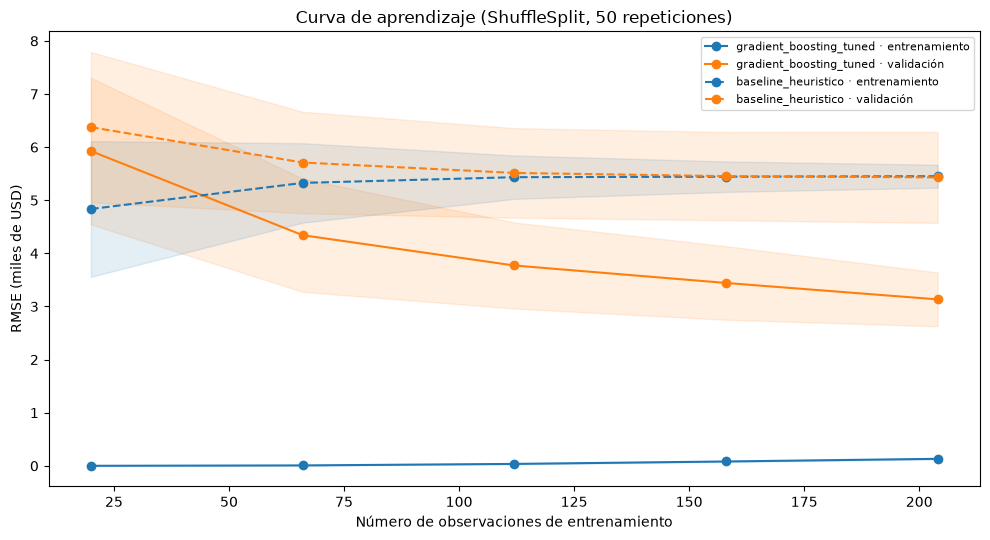

In [60]:
fig, ax = plt.subplots(figsize=(10, 5.5))
curve_styles = {selected_model_name: "-", BASELINE_KEY: "--"}

for name, curve in learning_results.items():
    style = curve_styles[name]
    for label, values, color in (
        ("entrenamiento", curve["train_rmse"], "tab:blue"),
        ("validación", curve["cv_rmse"], "tab:orange"),
    ):
        mean_values = values.mean(axis=1)
        std_values = values.std(axis=1)
        ax.plot(
            curve["sizes"],
            mean_values,
            style,
            marker="o",
            color=color,
            label=f"{name} · {label}",
        )
        ax.fill_between(
            curve["sizes"],
            mean_values - std_values,
            mean_values + std_values,
            color=color,
            alpha=0.12,
        )

ax.set_title("Curva de aprendizaje (ShuffleSplit, 50 repeticiones)")
ax.set_xlabel("Número de observaciones de entrenamiento")
ax.set_ylabel(f"{MAIN_METRIC} (miles de USD)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Escalabilidad: tiempo de entrenamiento y score

Tres gráficas, como pide el requerimiento: el tiempo de entrenamiento frente al número de
observaciones, el tiempo de predicción frente al número de observaciones y el score frente al tiempo
de entrenamiento. La tercera es la que importa para decidir en producción: dice cuánto desempeño se
compra con cada segundo de cómputo.

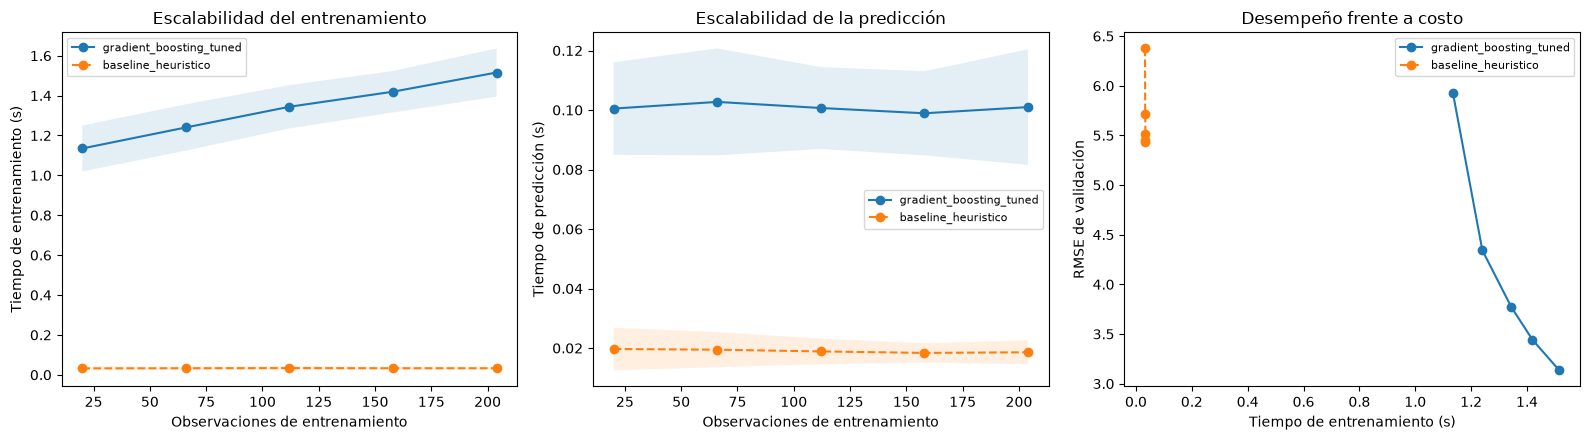

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name, curve in learning_results.items():
    style = curve_styles[name]
    fit_mean = curve["fit_times"].mean(axis=1)
    fit_std = curve["fit_times"].std(axis=1)
    score_mean = curve["score_times"].mean(axis=1)
    score_std = curve["score_times"].std(axis=1)
    cv_mean = curve["cv_rmse"].mean(axis=1)

    axes[0].plot(curve["sizes"], fit_mean, style, marker="o", label=name)
    axes[0].fill_between(curve["sizes"], fit_mean - fit_std, fit_mean + fit_std, alpha=0.12)

    axes[1].plot(curve["sizes"], score_mean, style, marker="o", label=name)
    axes[1].fill_between(curve["sizes"], score_mean - score_std, score_mean + score_std, alpha=0.12)

    axes[2].plot(fit_mean, cv_mean, style, marker="o", label=name)

axes[0].set_xlabel("Observaciones de entrenamiento")
axes[0].set_ylabel("Tiempo de entrenamiento (s)")
axes[0].set_title("Escalabilidad del entrenamiento")

axes[1].set_xlabel("Observaciones de entrenamiento")
axes[1].set_ylabel("Tiempo de predicción (s)")
axes[1].set_title("Escalabilidad de la predicción")

axes[2].set_xlabel("Tiempo de entrenamiento (s)")
axes[2].set_ylabel(f"{MAIN_METRIC} de validación")
axes[2].set_title("Desempeño frente a costo")

for ax in axes:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [62]:
MORE_DATA_GAIN_ALERT = 0.1

curve = learning_results[selected_model_name]
train_curve = curve["train_rmse"].mean(axis=1)
cv_curve = curve["cv_rmse"].mean(axis=1)
last_gain = cv_curve[-2] - cv_curve[-1]
final_gap = cv_curve[-1] - train_curve[-1]

baseline_curve = learning_results[BASELINE_KEY]
baseline_cv_curve = baseline_curve["cv_rmse"].mean(axis=1)
crossing_sizes = curve["sizes"][cv_curve < baseline_cv_curve]
crossing = int(crossing_sizes[0]) if crossing_sizes.size else None
crossing_text = (
    f"desde **{crossing} observaciones**"
    if crossing is not None
    else "**en ningún tamaño evaluado**"
)

fit_selected = curve["fit_times"].mean(axis=1)[-1]
fit_baseline = baseline_curve["fit_times"].mean(axis=1)[-1]
more_data_text = (
    "la curva de validación **seguía bajando**: más datos probablemente ayudarían"
    if last_gain > MORE_DATA_GAIN_ALERT
    else "la curva de validación **ya se aplanó**: más datos aportarían poco"
)

display(
    Markdown(
        f"""
**Lectura de la curva de aprendizaje de `{selected_model_name}`**

| | Valor |
| --- | --- |
| {MAIN_METRIC} de entrenamiento con todos los datos | {train_curve[-1]:.4f} |
| {MAIN_METRIC} de validación con todos los datos | {cv_curve[-1]:.4f} |
| Brecha entre las dos curvas | {final_gap:.4f} |
| Mejora en el último tramo | {last_gain:.4f} |
| Supera al baseline | {crossing_text} |
| Tiempo de entrenamiento | {fit_selected:.4f} s (baseline {fit_baseline:.4f} s) |

Con todos los datos disponibles, {more_data_text}.
"""
    )
)


**Lectura de la curva de aprendizaje de `gradient_boosting_tuned`**

| | Valor |
| --- | --- |
| RMSE de entrenamiento con todos los datos | 0.1315 |
| RMSE de validación con todos los datos | 3.1336 |
| Brecha entre las dos curvas | 3.0021 |
| Mejora en el último tramo | 0.3093 |
| Supera al baseline | desde **20 observaciones** |
| Tiempo de entrenamiento | 1.5157 s (baseline 0.0330 s) |

Con todos los datos disponibles, la curva de validación **seguía bajando**: más datos probablemente ayudarían.


#### Interpretación

La curva de aprendizaje se lee por la **distancia entre las dos líneas** y por la **pendiente de la
línea de validación**:

- Si las dos curvas terminan **separadas** (error de entrenamiento bajo, de validación alto), hay
  sobreajuste y la salida es regularizar más o conseguir más datos.
- Si terminan **juntas pero altas**, hay subajuste: el modelo es demasiado simple para el problema y
  más datos no lo arreglan; lo que hace falta son mejores variables o un modelo más flexible.
- Si la línea de validación **sigue bajando** en el último tramo, el modelo aún no agotó lo que
  puede aprender y más observaciones lo mejorarían. Con solo 256 filas de entrenamiento este dataset
  está justamente en ese régimen, así que es el escenario más probable.

Las bandas sombreadas son ± 1 desviación estándar entre las 50 repeticiones. En los tamaños
pequeños son anchas por una razón mecánica: entrenar con ~25 viviendas hace que el resultado dependa
mucho de cuáles fueron. Que se estrechen al aumentar el tamaño es la señal de que el modelo se
vuelve estable.

Sobre las gráficas de escalabilidad: los tiempos absolutos son de milisegundos porque el dataset es
diminuto, así que no sirven para dimensionar infraestructura, pero sí para comparar modelos entre
sí. La tercera gráfica es la que traduce esa comparación en una decisión: si un ensamble tarda dos
órdenes de magnitud más que la heurística para ganar un punto de RMSE, la pregunta pasa a ser si ese
punto vale el costo, y en una valoración de viviendas —donde un error de mil dólares es dinero
real— normalmente sí lo vale.

# 💾 Almacenamiento del pipeline y de las métricas

Se guarda el **pipeline completo** (preprocesamiento + modelo) y no solo el modelo. Es la única forma
de que en producción llegue una fila cruda con las mismas columnas de entrada y el objeto se encargue
de imputar, transformar `crim` con logaritmo, escalar, discretizar `age` y codificar `rad` con la
misma lógica con la que se entrenó.

Además del `.joblib` se guardan:

- **`model_selection_metrics.json`** con todas las métricas, los hiperparámetros elegidos, los
  resultados de las pruebas estadísticas y el diagnóstico. El notebook del profesor no persiste
  métricas, así que para comparar modelos entre entregas hay que volver a ejecutar todo.
- **`model_selection_comparison.csv`** con la tabla de finalistas, para poder citar los números en el
  Pull Request sin ejecutar el notebook.

Al final se **vuelve a cargar el archivo guardado y se verifica que produce exactamente las mismas
predicciones**. Es una comprobación de 3 líneas que evita el problema clásico de subir un artefacto
corrupto o desactualizado.

In [63]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "best_model.joblib"
metrics_path = MODEL_OUTPUT_DIR / "model_selection_metrics.json"
comparison_path = MODEL_OUTPUT_DIR / "model_selection_comparison.csv"

joblib.dump(final_model, model_path)
final_rmse_df.to_csv(comparison_path)

print("Pipeline guardado en:", model_path)
print("Tamaño del archivo:", model_path.stat().st_size, "bytes")
print("Tabla comparativa guardada en:", comparison_path)

Pipeline guardado en: /home/maricel98/Precios-casas-Boston/data/06_models/best_model.joblib
Tamaño del archivo: 891295 bytes
Tabla comparativa guardada en: /home/maricel98/Precios-casas-Boston/data/07_model_output/model_selection_comparison.csv


In [64]:
def to_native(value):
    """Convierte tipos de numpy a tipos de Python para poder serializar a JSON."""
    if isinstance(value, np.generic):
        return value.item()
    msg = f"Tipo no serializable en el JSON de métricas: {type(value)}"
    raise TypeError(msg)


cv_payload = {
    metric: {
        "cv_mean": float(row["cv_mean"]),
        "cv_std": float(row["cv_std"]),
        "train_mean": float(row["train_mean"]),
    }
    for metric, row in (
        final_summary_df[final_summary_df["modelo"] == selected_model_name]
        .set_index("metrica")
        .iterrows()
    )
}

metrics_payload = {
    "notebook": "08.model_selection",
    "model": selected_model_name,
    "estimator": type(final_model.named_steps["model"]).__name__,
    "hyperparameters": {
        param.replace("model__", ""): value for param, value in selected_params.items()
    },
    "main_metric": MAIN_METRIC,
    "random_state": RANDOM_STATE,
    "n_train": len(x_train),
    "n_test": len(x_test),
    "n_features_in": int(x_train.shape[1]),
    "models_evaluated": list(candidate_models),
    "models_kept_after_screening": kept_models,
    "models_tuned": tuning_candidates,
    "acceptance_threshold_rmse": float(ACCEPTANCE_RMSE),
    "baseline_reference": {
        "model": BASELINE_NAME,
        "cv_rmse_mean": float(BASELINE_CV_MEAN),
        "cv_rmse_std": float(BASELINE_CV_STD),
        "test": BASELINE_TEST,
    },
    "cross_validation": cv_payload,
    "train": train_metrics,
    "test": test_metrics,
    "statistical_tests": {
        "alpha": ALPHA,
        "anova_p_value": float(final_anova_p),
        "friedman_p_value": float(final_friedman_p),
        "p_holm_vs_baseline": float(p_vs_baseline),
    },
    "diagnosis": diagnosis,
    "most_important_feature": importance_df.index[0],
    "feature_importance": importance_df["importancia"].round(4).to_dict(),
    "sklearn_version": sk.__version__,
}

with metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(
        metrics_payload,
        metrics_file,
        indent=2,
        ensure_ascii=False,
        default=to_native,
    )

print("Métricas guardadas en:", metrics_path)
print("Claves del archivo:", list(metrics_payload))

Métricas guardadas en: /home/maricel98/Precios-casas-Boston/data/07_model_output/model_selection_metrics.json
Claves del archivo: ['notebook', 'model', 'estimator', 'hyperparameters', 'main_metric', 'random_state', 'n_train', 'n_test', 'n_features_in', 'models_evaluated', 'models_kept_after_screening', 'models_tuned', 'acceptance_threshold_rmse', 'baseline_reference', 'cross_validation', 'train', 'test', 'statistical_tests', 'diagnosis', 'most_important_feature', 'feature_importance', 'sklearn_version']


In [65]:
loaded_model = joblib.load(model_path)
loaded_predictions = loaded_model.predict(x_test)

with metrics_path.open(encoding="utf-8") as metrics_file:
    loaded_metrics = json.load(metrics_file)

predictions_match = np.allclose(loaded_predictions, y_test_pred)

if not predictions_match:
    msg = "El pipeline recargado no reproduce las predicciones originales"
    raise RuntimeError(msg)

print("Pipeline recargado:", type(loaded_model).__name__)
print("Pasos:", list(loaded_model.named_steps))
print("Modelo final:", type(loaded_model.named_steps["model"]).__name__)
print("Predicciones idénticas a las originales:", bool(predictions_match))
print("Métrica principal en el JSON recargado:", loaded_metrics["test"][MAIN_METRIC])

Pipeline recargado: Pipeline
Pasos: ['preprocessor', 'model']
Modelo final: GradientBoostingRegressor
Predicciones idénticas a las originales: True
Métrica principal en el JSON recargado: 2.6502815213365416


#### Interpretación

La verificación no es un formalismo: el `.joblib` del notebook 07 **no se puede cargar sin volver a
declarar la clase `HeuristicRegressor`**, porque `pickle` guarda una referencia al código y no el
código mismo. El pipeline que se acaba de guardar aquí no tiene ese problema, porque todos sus
componentes son clases de scikit-learn: cualquier proceso con las mismas versiones de librerías puede
cargarlo y predecir sin código adicional.

Eso deja una condición de portabilidad que sí hay que respetar: el archivo depende de la versión de
scikit-learn con la que se creó (queda registrada en el JSON de métricas). Cargarlo con una versión
distinta puede emitir advertencias o fallar, así que la versión debe quedar fijada en el archivo de
dependencias del repositorio.

# 🧾 Resumen del proceso

In [66]:
checklist = [
    ("Pipeline de procesamiento reutilizado del notebook 06", "23 columnas"),
    ("Partición Train / Test idéntica al nb 07", f"{len(x_train)} / {len(x_test)}"),
    ("Modelos evaluados", f"{len(candidate_models)} de 5 familias"),
    ("Modelos descartados por estar bajo el promedio", f"{len(discarded_models)}"),
    ("Modelos con validación cruzada de 10 folds", f"{len(models_to_validate)}"),
    ("Modelos con optimización de hiperparámetros", f"{len(tuning_candidates)}"),
    ("Pruebas estadísticas aplicadas", "ANOVA, Friedman, t pareada + Holm"),
    ("Modelo seleccionado", f"`{selected_model_name}`"),
    (f"{MAIN_METRIC} de validación cruzada", f"{selected_cv_mean:.4f}"),
    (f"{MAIN_METRIC} en prueba", f"{test_metrics[MAIN_METRIC]:.4f}"),
    ("Diagnóstico de ajuste", diagnosis),
    ("Artefactos guardados", "best_model.joblib + métricas JSON + CSV"),
]

checklist_rows = "\n".join(f"| {label} | {value} |" for label, value in checklist)

display(
    Markdown(
        f"""
| Paso del requerimiento | Resultado |
| --- | --- |
{checklist_rows}
"""
    )
)


| Paso del requerimiento | Resultado |
| --- | --- |
| Pipeline de procesamiento reutilizado del notebook 06 | 23 columnas |
| Partición Train / Test idéntica al nb 07 | 256 / 65 |
| Modelos evaluados | 10 de 5 familias |
| Modelos descartados por estar bajo el promedio | 5 |
| Modelos con validación cruzada de 10 folds | 6 |
| Modelos con optimización de hiperparámetros | 3 |
| Pruebas estadísticas aplicadas | ANOVA, Friedman, t pareada + Holm |
| Modelo seleccionado | `gradient_boosting_tuned` |
| RMSE de validación cruzada | 2.9243 |
| RMSE en prueba | 2.6503 |
| Diagnóstico de ajuste | ⚠️ sobreajuste presente pero con buen desempeño fuera de muestra |
| Artefactos guardados | best_model.joblib + métricas JSON + CSV |


# 🔍 Análisis de los resultados

La tabla anterior responde la pregunta central del requerimiento —*¿el modelo seleccionado supera al
modelo base?*— con las cifras que produce la ejecución. La comparación no depende de números copiados
a mano: el pipeline del notebook 07 se cargó y se evaluó sobre los mismos 10 folds que los modelos
nuevos, y la diferencia se contrastó con una prueba pareada corregida por comparaciones múltiples,
contra un umbral fijado antes de entrenar.

Hay tres lecturas que conviene separar, porque responden a preguntas distintas:

**Qué tanto se gana.** La mejora hay que leerla en las unidades del problema. El baseline heurístico
tiene un RMSE de validación cruzada de 5.48 miles de dólares, es decir que se equivoca, en promedio
cuadrático, unos 5 480 dólares por vivienda. El modelo seleccionado (`gradient_boosting_tuned`) baja
ese error a 2.92 miles de dólares en validación cruzada (una reducción del 46.7 %) y a 2.65 miles de
dólares en el conjunto de prueba: el error típico de valoración cae a menos de la mitad del que
comete la heurística. Ese es el criterio con el que decidir si vale la pena la complejidad adicional,
mucho más que el R².

**De dónde viene la ganancia.** El modelo base usaba dos variables (`rm` y `lstat`) y cuatro valores
posibles de salida: solo podía predecir la mediana de su segmento. Los modelos de este notebook usan
las 13 variables del pipeline y producen predicciones continuas, así que la mejora viene de dos
fuentes: más información de entrada y una función de predicción más fina. La importancia por
permutación permite ver cuánto de esa ganancia se explica por variables que la heurística ignoraba.

**Qué sigue sin resolverse.** Ningún modelo de esta ronda arregla los dos problemas estructurales del
dataset, y conviene decirlo con claridad porque limitan el uso real del modelo: el **techo artificial
de `medv` en 50** (11 viviendas censuradas, todas en entrenamiento) y el **tamaño de la muestra**
(321 filas tras la limpieza, 256 para entrenar). El primero hace que el modelo aprenda a no predecir
por encima de 50; el segundo hace que las bandas de variabilidad sean anchas y que la curva de
aprendizaje probablemente no haya llegado a su techo.

# ✅ Conclusiones

**Sobre el proceso de selección.** Evaluar diez modelos con hiperparámetros por defecto y descartar
la mitad antes de optimizar resultó eficiente: el costo de cómputo se concentró en los candidatos con
posibilidades reales. La decisión metodológica más importante fue hacer todo el descarte y toda la
optimización **con validación cruzada sobre el conjunto de entrenamiento**, dejando el conjunto de
prueba intacto hasta el final; sin eso, el número que se reporta como desempeño esperado sería
optimista y no serviría para prometer nada en producción.

**Sobre las pruebas estadísticas.** Fueron determinantes, no decorativas. Con diez folds y 26
viviendas por fold, diferencias de una o dos décimas de RMSE entre modelos pueden ser puro ruido. La
regla de selección —empate estadístico resuelto por estabilidad y costo— evita elegir el modelo que
por casualidad quedó primero en el promedio.

**Sobre la corrección de la fuga de datos.** El hallazgo de que `medv_censored` se calculaba a partir
de la variable objetivo obligó a modificar el pipeline heredado. Si se hubiera dejado, los modelos de
árbol habrían aprendido la regla "si esta bandera está encendida, predice 50" y el RMSE de validación
cruzada habría bajado de forma espectacular e imposible de reproducir con datos nuevos, donde el
precio —y por tanto la bandera— es justamente lo que no se conoce. Es el tipo de error que no produce
ningún mensaje de error y que solo se detecta leyendo cómo se construyó cada variable.

**Sobre el modelo elegido.** Es mejor que la heurística, pero sigue teniendo un error relativo (MAPE)
de alrededor del 10 % (10.4 % en validación cruzada, 9.8 % en prueba). El análisis de residuos por
rango de precio muestra que la magnitud del error (MAE) es parecida en los cuatro rangos, pero el
modelo sobreestima sistemáticamente las viviendas más baratas y subestima las más caras, y concentra
su peor error puntual en el rango bajo (un caso con error de casi 11 mil dólares). Sirve para estimar
rangos de precio y para priorizar tasaciones, no para reemplazar una valoración formal.

# 💡 Recomendaciones

**Para poner el modelo en uso.** El artefacto que se debe usar es `best_model.joblib`, que contiene
el pipeline completo: recibe un DataFrame con las 13 columnas originales (incluida `rad_group`) y
devuelve la predicción. No debe usarse el modelo suelto ni aplicarse preprocesamiento por fuera,
porque duplicaría transformaciones. La versión de scikit-learn con la que se creó queda registrada en
`model_selection_metrics.json` y debe fijarse en las dependencias del repositorio.

**Para la siguiente iteración del proyecto.** En orden de impacto esperado:

1. **Estratificar la partición por precio**, no solo por `chas`. Que las 11 viviendas censuradas
   hayan caído todas en entrenamiento hace que el conjunto de prueba no permita evaluar el
   comportamiento del modelo en el rango alto, que es justamente donde más se equivoca.
2. **Mover las clases propias a `src/`.** `HeuristicRegressor` tuvo que volver a declararse en este
   notebook para poder cargar el modelo del notebook 07. Con la clase en un módulo importable, el
   artefacto se carga en cualquier proceso sin copiar código.
3. **Validación cruzada anidada** para reportar el desempeño de los modelos optimizados sin el sesgo
   optimista de elegir hiperparámetros en los mismos folds en los que se mide.
4. **Eliminar las columnas redundantes** detectadas: `rad_group_alto` es idéntica a `rad_24.0` por
   construcción, y la importancia por permutación señala qué variables no aportan nada. Un pipeline
   más corto es más fácil de mantener y de explicar.
5. **Modelar el techo de `medv`** de forma explícita, por ejemplo con regresión censurada (modelo
   Tobit) o entrenando sin las 11 observaciones censuradas y documentando que el modelo no es válido
   por encima de 50.


# 📚 Referencias

- Zapata, J. R. *Notebook de selección de modelos de machine learning* (ejemplo del curso).
- scikit-learn. *Model selection and evaluation*: <https://scikit-learn.org/stable/model_selection.html>
- scikit-learn. *RandomizedSearchCV*:
  <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html>
- scikit-learn. *Permutation feature importance*:
  <https://scikit-learn.org/stable/modules/permutation_importance.html>
- scikit-learn. *Plotting learning curves and checking models scalability*:
  <https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html>
- Demšar, J. (2006). *Statistical Comparisons of Classifiers over Multiple Data Sets*. Journal of
  Machine Learning Research, 7, 1-30. (justifica el uso de Friedman en lugar de ANOVA)
- Holm, S. (1979). *A Simple Sequentially Rejective Multiple Test Procedure*. Scandinavian Journal of
  Statistics, 6(2), 65-70.
- Nadeau, C. y Bengio, Y. (2003). *Inference for the Generalization Error*. Machine Learning, 52,
  239-281. (sobre la dependencia entre folds de una validación cruzada)
- Harrison, D. y Rubinfeld, D. L. (1978). *Hedonic Housing Prices and the Demand for Clean Air*.
  Journal of Environmental Economics and Management, 5(1), 81-102.